# Laboratorium 3 – Klasyfikacja: Indukcja drzew decyzyjnych za pomocą CART

**Przedmiot:** Uczenie maszynowe – laboratorium  
**Algorytm:** Classification and Regression Trees (CART)  
**Zbiory danych:** GLASS (UCI id=42), Polish Companies Bankruptcy (PCB)


## 0. Import bibliotek

In [50]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches 
import seaborn as sns
from matplotlib.colors import ListedColormap
from sklearn.tree import (
    DecisionTreeClassifier, export_text, plot_tree
)
from sklearn.model_selection import (
    train_test_split, cross_val_score,
    StratifiedKFold, KFold, learning_curve
)
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay,
    f1_score, roc_auc_score
)
from sklearn.preprocessing import label_binarize, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.base import BaseEstimator, TransformerMixin
import warnings
warnings.filterwarnings('ignore')

# Styl wykresów
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11
sns.set_theme(style='whitegrid', palette='muted')
print('Biblioteki zaimportowane poprawnie.')

Biblioteki zaimportowane poprawnie.


### 1.1 Zbiór GLASS

In [51]:
from ucimlrepo import fetch_ucirepo

glass_repo = fetch_ucirepo(id=42)
X_glass = glass_repo.data.features
y_glass = glass_repo.data.targets.iloc[:, 0].rename('class')

class_names_glass = {
    1:'building_float', 2:'building_non_float', 3:'vehicle_float',
    5:'vehicle_non_float', 6:'containers', 7:'tableware'
}
target_names_glass = [class_names_glass[k] for k in sorted(y_glass.unique())]

print(f'Kształt danych: {X_glass.shape}')
print(f'Klasy: {target_names_glass}')
print(f'Rozkład klas:\n{y_glass.value_counts().sort_index()}')
X_glass.describe().T


Kształt danych: (214, 9)
Klasy: ['building_float', 'building_non_float', 'vehicle_float', 'vehicle_non_float', 'containers', 'tableware']
Rozkład klas:
class
1    70
2    76
3    17
5    13
6     9
7    29
Name: count, dtype: int64


,count,mean,std,min,25%,50%,75%,max
RI,214.0,1.518365,0.003037,1.51115,1.516522,1.51768,1.519157,1.53393
Na,214.0,13.407850,0.816604,10.73000,12.907500,13.30000,13.825000,17.38000
Mg,214.0,2.684533,1.442408,0.00000,2.115000,3.48000,3.600000,4.49000
Al,214.0,1.444907,0.499270,0.29000,1.190000,1.36000,1.630000,3.50000
Si,214.0,72.650935,0.774546,69.81000,72.280000,72.79000,73.087500,75.41000
K,214.0,0.497056,0.652192,0.00000,0.122500,0.55500,0.610000,6.21000
Ca,214.0,8.956963,1.423153,5.43000,8.240000,8.60000,9.172500,16.19000
Ba,214.0,0.175047,0.497219,0.00000,0.000000,0.00000,0.000000,3.15000
Fe,214.0,0.057009,0.097439,0.00000,0.000000,0.00000,0.100000,0.51000


### 1.2 Zbiór Polish Companies Bankruptcy (PCB)

Wczytujemy oryginalny zbiór z UCI ML Repository (id=365). Zawiera dane finansowe polskich firm z lat 2000–2012 – silnie niezbalansowane klasy i brakujące wartości.

In [52]:
from ucimlrepo import fetch_ucirepo

polish_companies_bankruptcy = fetch_ucirepo(id=365)

X_pcb_df = polish_companies_bankruptcy.data.features
y_pcb_s  = polish_companies_bankruptcy.data.targets.squeeze().rename('bankrupt')


class IQRClipper(BaseEstimator, TransformerMixin):
    def __init__(self, k=1.5):
        self.k = k

    def fit(self, X, y=None):
        X = np.array(X)
        Q1 = np.nanpercentile(X, 25, axis=0)
        Q3 = np.nanpercentile(X, 75, axis=0)
        IQR = Q3 - Q1
        self.lower_ = Q1 - self.k * IQR
        self.upper_ = Q3 + self.k * IQR
        return self

    def transform(self, X, y=None):
        X = np.array(X, dtype=float)
        return np.clip(X, self.lower_, self.upper_)


preprocessor = Pipeline([
    ('median_imputer', SimpleImputer(strategy='median')),
    ('iqr_clipper',    IQRClipper(k=1.5)),
    ('scaler',         StandardScaler()),
])

X_pcb_imp = preprocessor.fit_transform(X_pcb_df)
X_pcb_imp = pd.DataFrame(X_pcb_imp, columns=X_pcb_df.columns)

print(f'PCB – kształt: {X_pcb_df.shape}')
print(f'Rozkład klas: {y_pcb_s.value_counts().to_dict()}')
pct = y_pcb_s.sum() / len(y_pcb_s) * 100
print(f'Udział bankructw: {pct:.1f}%')

PCB – kształt: (43405, 65)
Rozkład klas: {0: 41314, 1: 2091}
Udział bankructw: 4.8%


---
## 2. Domyślne drzewo decyzyjne – GLASS

In [ ]:
# Podział danych
X_tr_g, X_te_g, y_tr_g, y_te_g = train_test_split(
    X_glass, y_glass, test_size=0.25, stratify=y_glass
)

# Domyślne drzewo
dt_default = DecisionTreeClassifier()
dt_default.fit(X_tr_g, y_tr_g)
y_pred_default = dt_default.predict(X_te_g)

print('=== Domyślne drzewo CART – GLASS ===')
print(f'Głębokość: {dt_default.get_depth()}')
print(f'Liczba liści: {dt_default.get_n_leaves()}')
print(f'Dokładność (test): {accuracy_score(y_te_g, y_pred_default):.4f}')
print(f'Dokładność (train): {accuracy_score(y_tr_g, dt_default.predict(X_tr_g)):.4f}')
print()
print(classification_report(y_te_g, y_pred_default,
                             target_names=target_names_glass))

=== Domyślne drzewo CART – GLASS ===
Głębokość: 11
Liczba liści: 40
Dokładność (test): 0.7037
Dokładność (train): 1.0000

                    precision    recall  f1-score   support

    building_float       0.80      0.89      0.84        18
building_non_float       0.82      0.47      0.60        19
     vehicle_float       0.33      0.50      0.40         4
 vehicle_non_float       1.00      0.67      0.80         3
        containers       0.17      0.50      0.25         2
         tableware       0.89      1.00      0.94         8

          accuracy                           0.70        54
         macro avg       0.67      0.67      0.64        54
      weighted avg       0.77      0.70      0.71        54



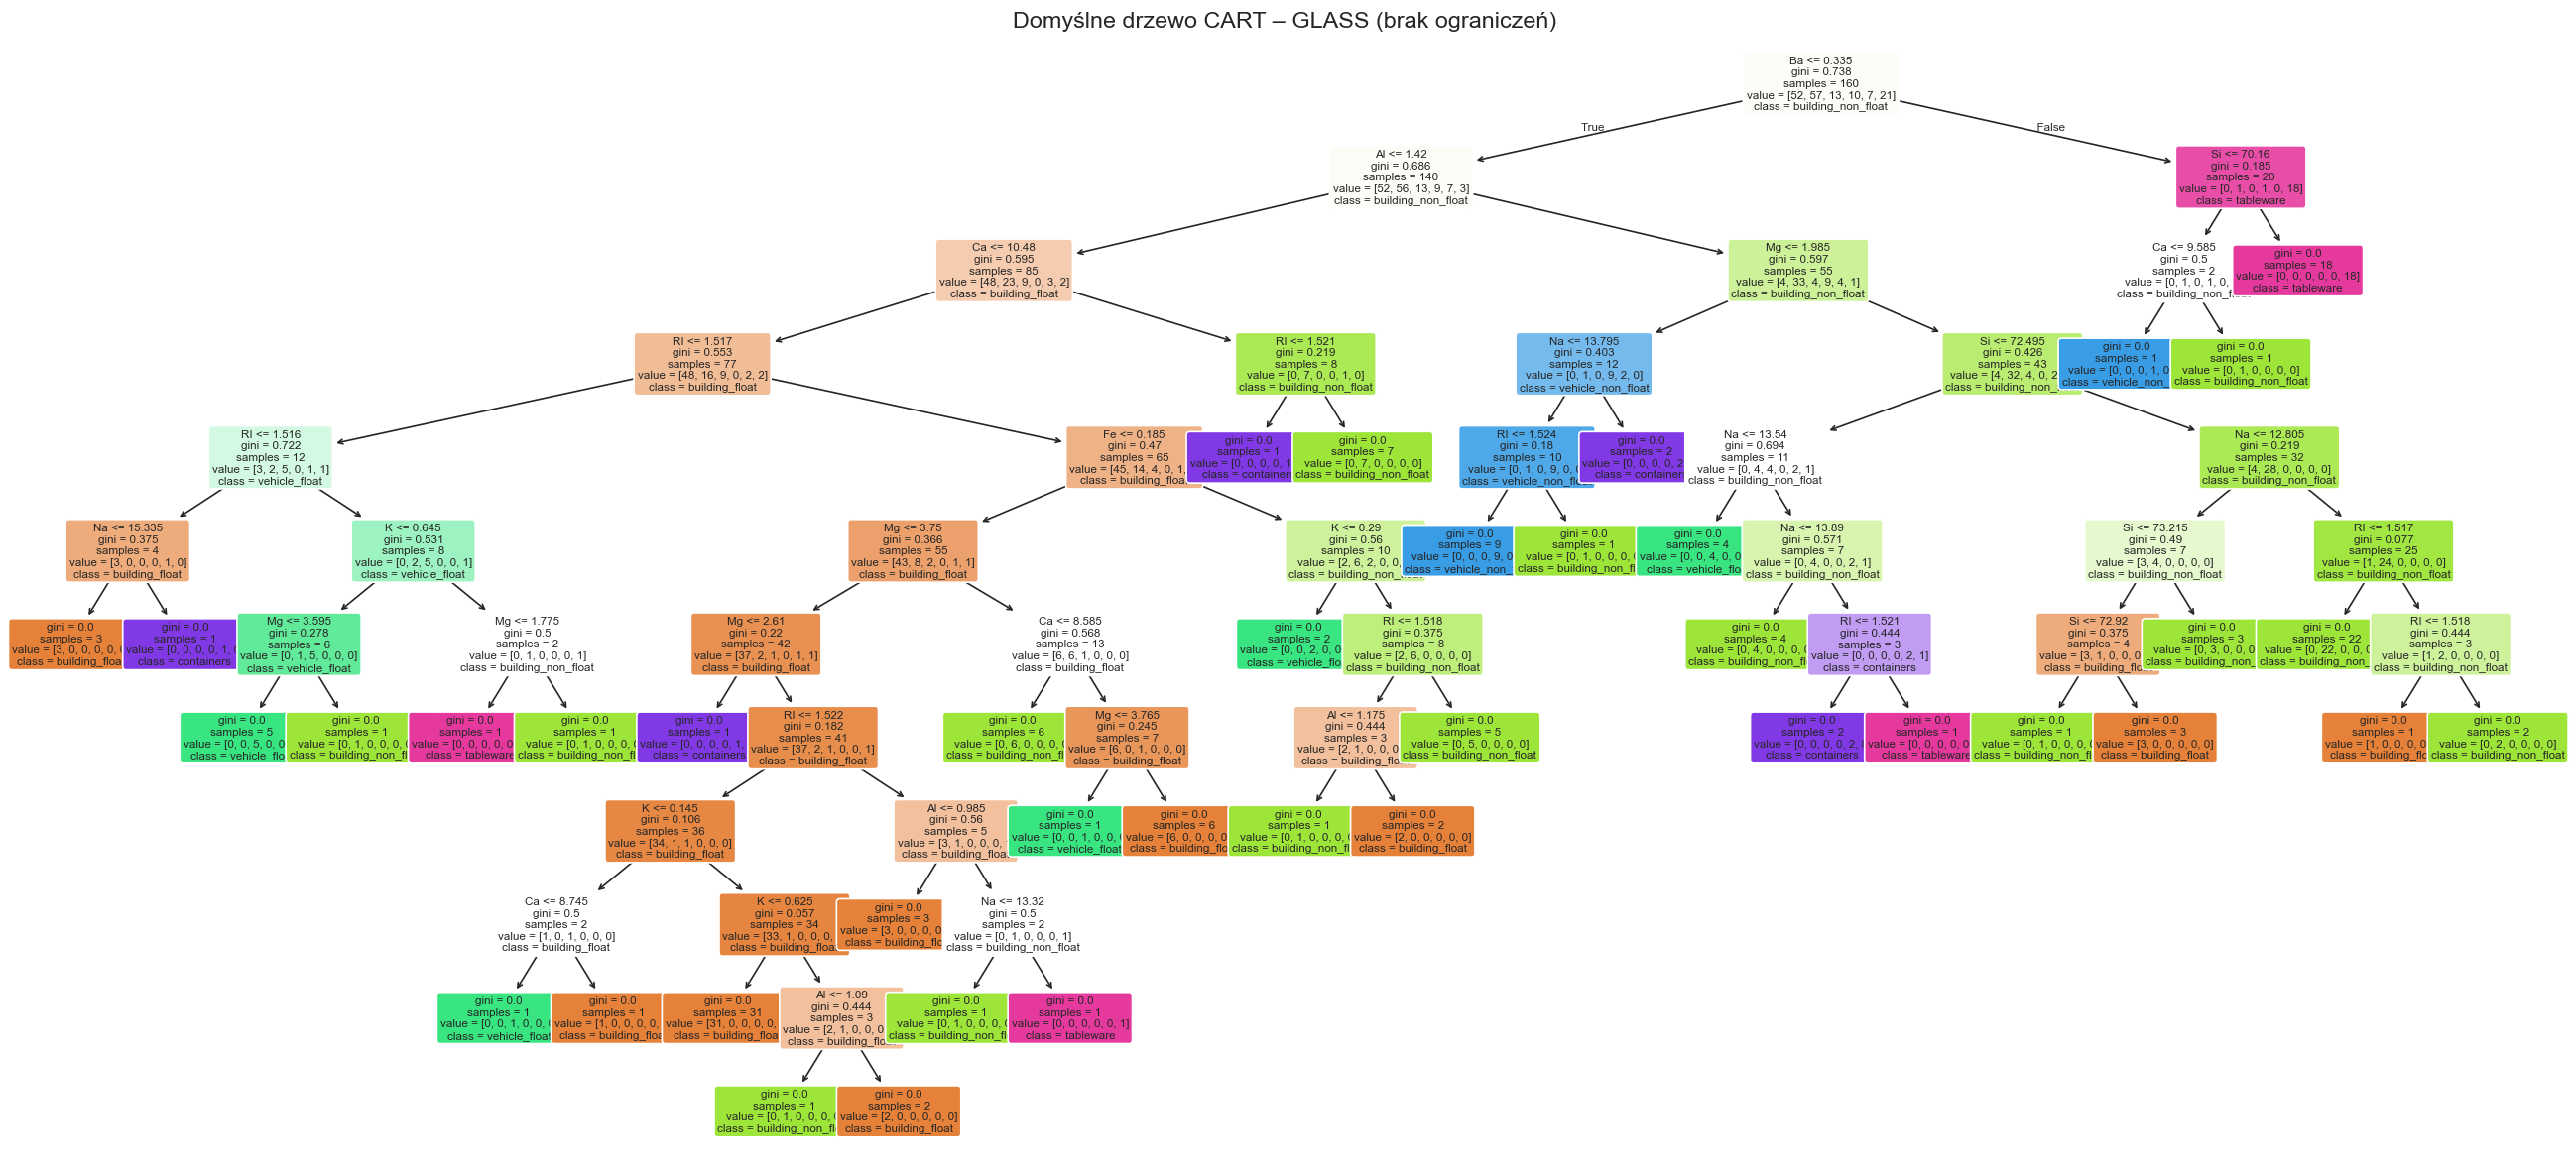

In [54]:
fig, ax = plt.subplots(figsize=(22, 10))
plot_tree(dt_default, ax=ax,
          feature_names=X_glass.columns.tolist(),
          class_names=target_names_glass,
          filled=True, rounded=True,
          impurity=True, fontsize=7)
ax.set_title('Domyślne drzewo CART – GLASS (brak ograniczeń)', fontsize=14)
plt.tight_layout()
plt.show()

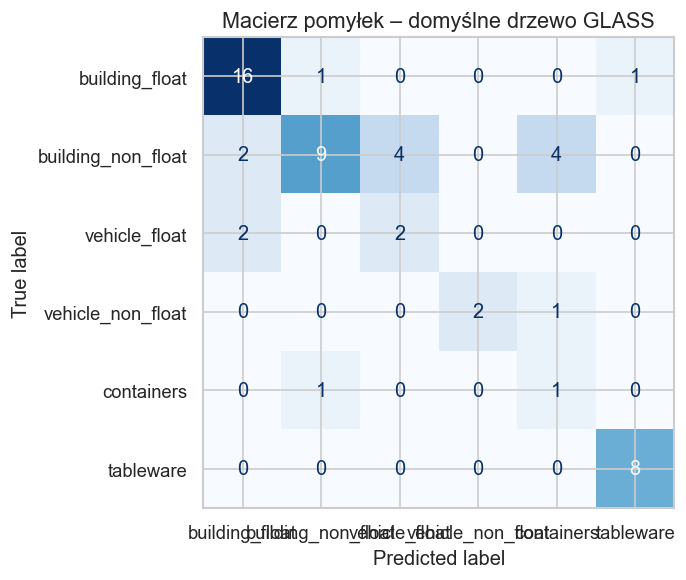

In [55]:
fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_te_g, y_pred_default)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=target_names_glass)
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Macierz pomyłek – domyślne drzewo GLASS', fontsize=13)
plt.tight_layout()
plt.show()

### 3.1 Wpływ `max_depth`

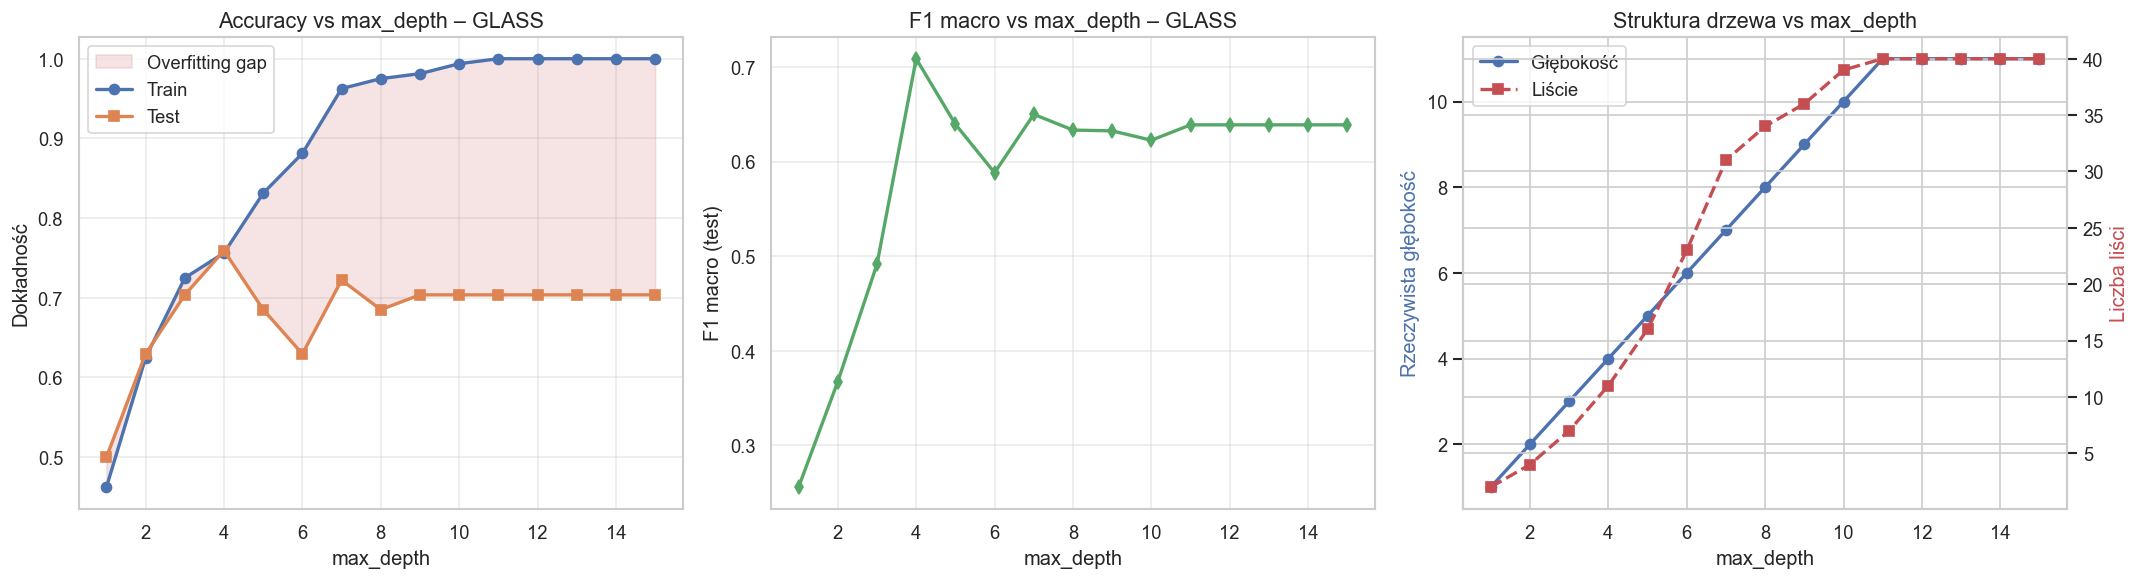

In [ ]:
depths = range(1, 16)
train_acc, test_acc, n_leaves, depth_vals, f1_test = [], [], [], [], []

for d in depths:
    clf = DecisionTreeClassifier(max_depth=d)
    clf.fit(X_tr_g, y_tr_g)
    y_pred = clf.predict(X_te_g)
    train_acc.append(accuracy_score(y_tr_g, clf.predict(X_tr_g)))
    test_acc.append(accuracy_score(y_te_g, y_pred))
    f1_test.append(f1_score(y_te_g, y_pred, average='macro'))
    n_leaves.append(clf.get_n_leaves())
    depth_vals.append(clf.get_depth())

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Accuracy
axes[0].fill_between(depths, train_acc, test_acc, alpha=0.15, color='#C44E52', label='Overfitting gap')
axes[0].plot(depths, train_acc, 'o-', label='Train', color='#4C72B0', linewidth=2)
axes[0].plot(depths, test_acc,  's-', label='Test',  color='#DD8452', linewidth=2)
axes[0].set_xlabel('max_depth'); axes[0].set_ylabel('Dokładność')
axes[0].set_title('Accuracy vs max_depth – GLASS', fontsize=13)
axes[0].legend(); axes[0].grid(True, alpha=0.4)

# F1
axes[1].plot(depths, f1_test, 'd-', color='#55A868', linewidth=2)
axes[1].set_xlabel('max_depth'); axes[1].set_ylabel('F1 macro (test)')
axes[1].set_title('F1 macro vs max_depth – GLASS', fontsize=13)
axes[1].grid(True, alpha=0.4)

# Struktura
ax3 = axes[2]
ax3b = ax3.twinx()
ax3.plot(depths, depth_vals,  'o-', color='#4C72B0', linewidth=2, label='Głębokość')
ax3b.plot(depths, n_leaves, 's--', color='#C44E52', linewidth=2, label='Liście')
ax3.set_xlabel('max_depth'); ax3.set_ylabel('Rzeczywista głębokość', color='#4C72B0')
ax3b.set_ylabel('Liczba liści', color='#C44E52')
ax3.set_title('Struktura drzewa vs max_depth', fontsize=13)
lines1, labs1 = ax3.get_legend_handles_labels()
lines2, labs2 = ax3b.get_legend_handles_labels()
ax3.legend(lines1+lines2, labs1+labs2, loc='upper left')

plt.tight_layout(); plt.show()


### 3.2 Wpływ `min_samples_leaf`

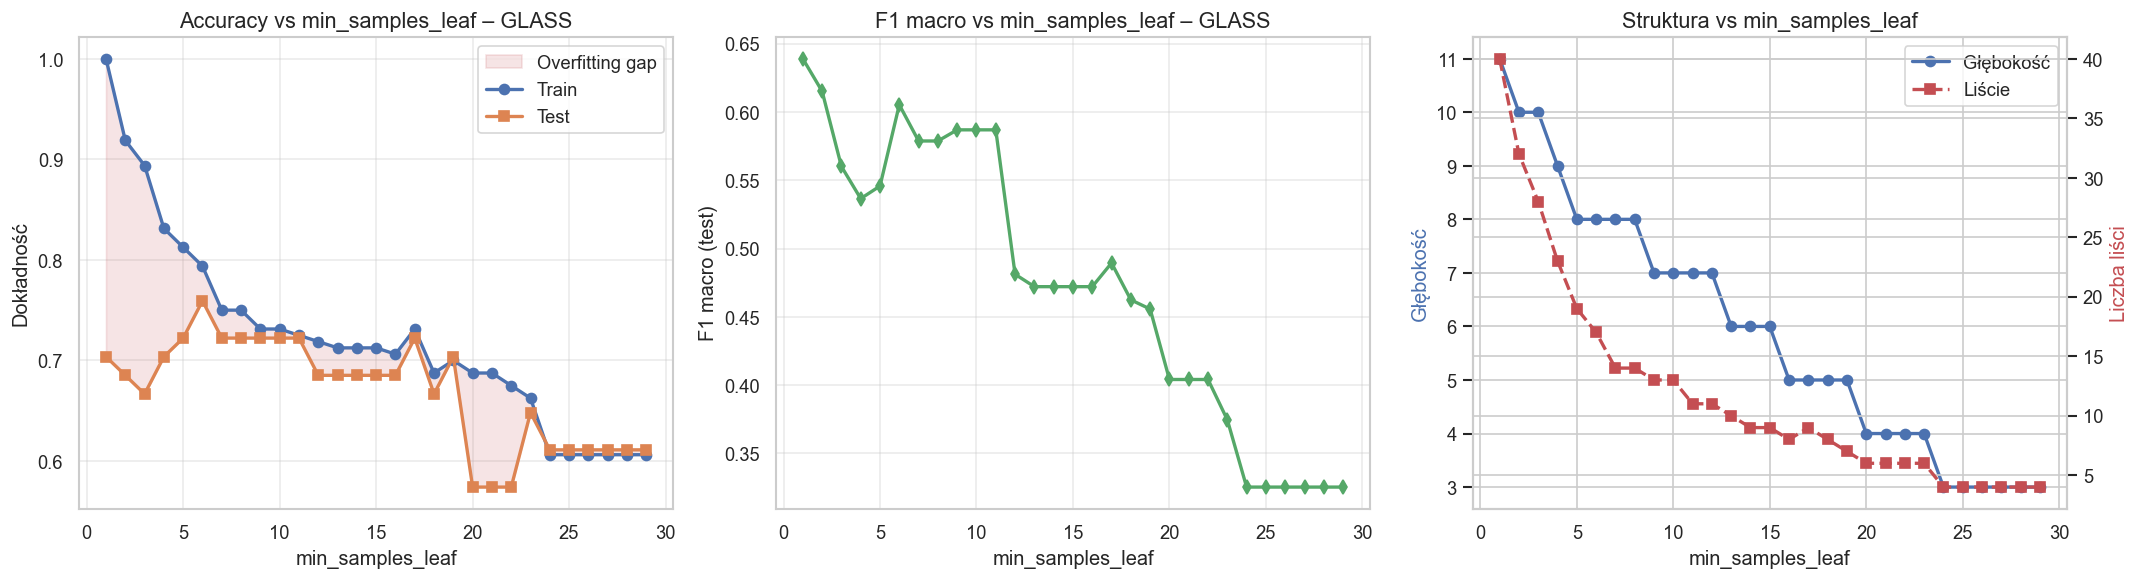

Najlepszy min_samples_leaf: 6 (acc=0.7593)


In [ ]:
leaf_sizes = range(1, 30)
train_msl, test_msl, depth_msl, leaves_msl, f1_msl = [], [], [], [], []

for msl in leaf_sizes:
    clf = DecisionTreeClassifier(min_samples_leaf=msl)
    clf.fit(X_tr_g, y_tr_g)
    y_pred = clf.predict(X_te_g)
    train_msl.append(accuracy_score(y_tr_g, clf.predict(X_tr_g)))
    test_msl.append(accuracy_score(y_te_g, y_pred))
    f1_msl.append(f1_score(y_te_g, y_pred, average='macro'))
    depth_msl.append(clf.get_depth())
    leaves_msl.append(clf.get_n_leaves())

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].fill_between(leaf_sizes, train_msl, test_msl, alpha=0.15, color='#C44E52', label='Overfitting gap')
axes[0].plot(leaf_sizes, train_msl, 'o-', label='Train', color='#4C72B0', linewidth=2)
axes[0].plot(leaf_sizes, test_msl,  's-', label='Test',  color='#DD8452', linewidth=2)
axes[0].set_xlabel('min_samples_leaf'); axes[0].set_ylabel('Dokładność')
axes[0].set_title('Accuracy vs min_samples_leaf – GLASS', fontsize=13)
axes[0].legend(); axes[0].grid(True, alpha=0.4)

axes[1].plot(leaf_sizes, f1_msl, 'd-', color='#55A868', linewidth=2)
axes[1].set_xlabel('min_samples_leaf'); axes[1].set_ylabel('F1 macro (test)')
axes[1].set_title('F1 macro vs min_samples_leaf – GLASS', fontsize=13)
axes[1].grid(True, alpha=0.4)

ax3 = axes[2]; ax3b = ax3.twinx()
ax3.plot(leaf_sizes, depth_msl,  'o-', color='#4C72B0', linewidth=2, label='Głębokość')
ax3b.plot(leaf_sizes, leaves_msl,'s--', color='#C44E52', linewidth=2, label='Liście')
ax3.set_xlabel('min_samples_leaf'); ax3.set_ylabel('Głębokość', color='#4C72B0')
ax3b.set_ylabel('Liczba liści', color='#C44E52')
ax3.set_title('Struktura vs min_samples_leaf', fontsize=13)
lines1, labs1 = ax3.get_legend_handles_labels()
lines2, labs2 = ax3b.get_legend_handles_labels()
ax3.legend(lines1+lines2, labs1+labs2, loc='upper right')

plt.tight_layout(); plt.show()
print(f'Najlepszy min_samples_leaf: {list(leaf_sizes)[np.argmax(test_msl)]} (acc={max(test_msl):.4f})')


### 3.3 Pruning – wpływ `ccp_alpha`

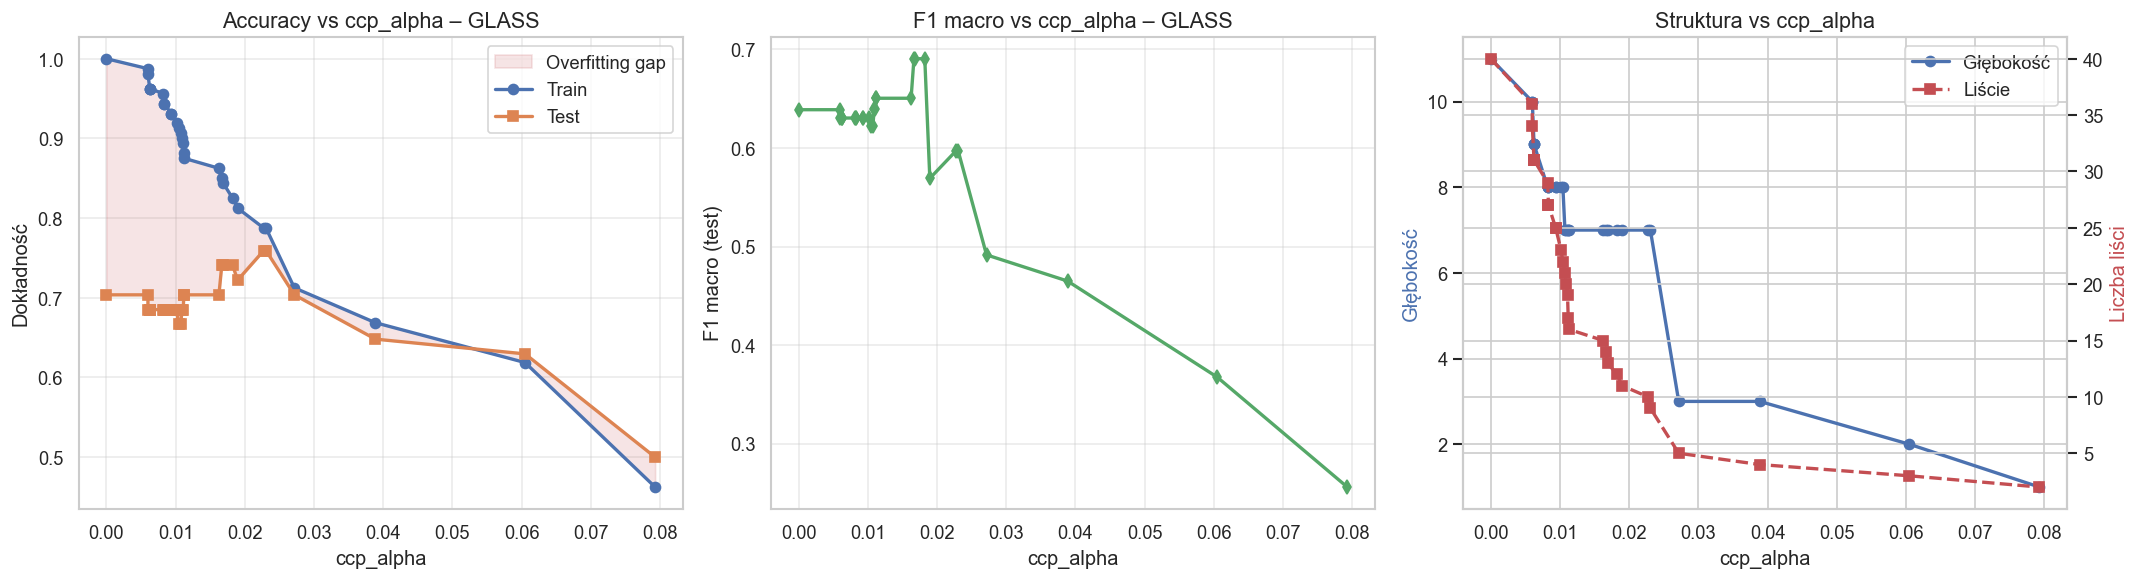

Najlepsza ccp_alpha: 0.02273


In [ ]:
clf_full = DecisionTreeClassifier()
path = clf_full.cost_complexity_pruning_path(X_tr_g, y_tr_g)
ccp_alphas  = path.ccp_alphas
impurities  = path.impurities
alphas_test = ccp_alphas[:-1]

train_ccp, test_ccp, depth_ccp, leaves_ccp, f1_ccp = [], [], [], [], []

for alpha in alphas_test:
    clf = DecisionTreeClassifier(ccp_alpha=alpha)
    clf.fit(X_tr_g, y_tr_g)
    y_pred = clf.predict(X_te_g)
    train_ccp.append(accuracy_score(y_tr_g, clf.predict(X_tr_g)))
    test_ccp.append(accuracy_score(y_te_g, y_pred))
    f1_ccp.append(f1_score(y_te_g, y_pred, average='macro'))
    depth_ccp.append(clf.get_depth())
    leaves_ccp.append(clf.get_n_leaves())

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].fill_between(alphas_test, train_ccp, test_ccp, alpha=0.15, color='#C44E52', label='Overfitting gap')
axes[0].plot(alphas_test, train_ccp, 'o-', label='Train', color='#4C72B0', linewidth=2)
axes[0].plot(alphas_test, test_ccp,  's-', label='Test',  color='#DD8452', linewidth=2)
axes[0].set_xlabel('ccp_alpha'); axes[0].set_ylabel('Dokładność')
axes[0].set_title('Accuracy vs ccp_alpha – GLASS', fontsize=13)
axes[0].legend(); axes[0].grid(True, alpha=0.4)

axes[1].plot(alphas_test, f1_ccp, 'd-', color='#55A868', linewidth=2)
axes[1].set_xlabel('ccp_alpha'); axes[1].set_ylabel('F1 macro (test)')
axes[1].set_title('F1 macro vs ccp_alpha – GLASS', fontsize=13)
axes[1].grid(True, alpha=0.4)

ax3 = axes[2]; ax3b = ax3.twinx()
ax3.plot(alphas_test, depth_ccp,  'o-', color='#4C72B0', linewidth=2, label='Głębokość')
ax3b.plot(alphas_test, leaves_ccp,'s--', color='#C44E52', linewidth=2, label='Liście')
ax3.set_xlabel('ccp_alpha'); ax3.set_ylabel('Głębokość', color='#4C72B0')
ax3b.set_ylabel('Liczba liści', color='#C44E52')
ax3.set_title('Struktura vs ccp_alpha', fontsize=13)
lines1, labs1 = ax3.get_legend_handles_labels()
lines2, labs2 = ax3b.get_legend_handles_labels()
ax3.legend(lines1+lines2, labs1+labs2, loc='upper right')

plt.tight_layout(); plt.show()
print(f'Najlepsza ccp_alpha: {alphas_test[np.argmax(test_ccp)]:.5f}')


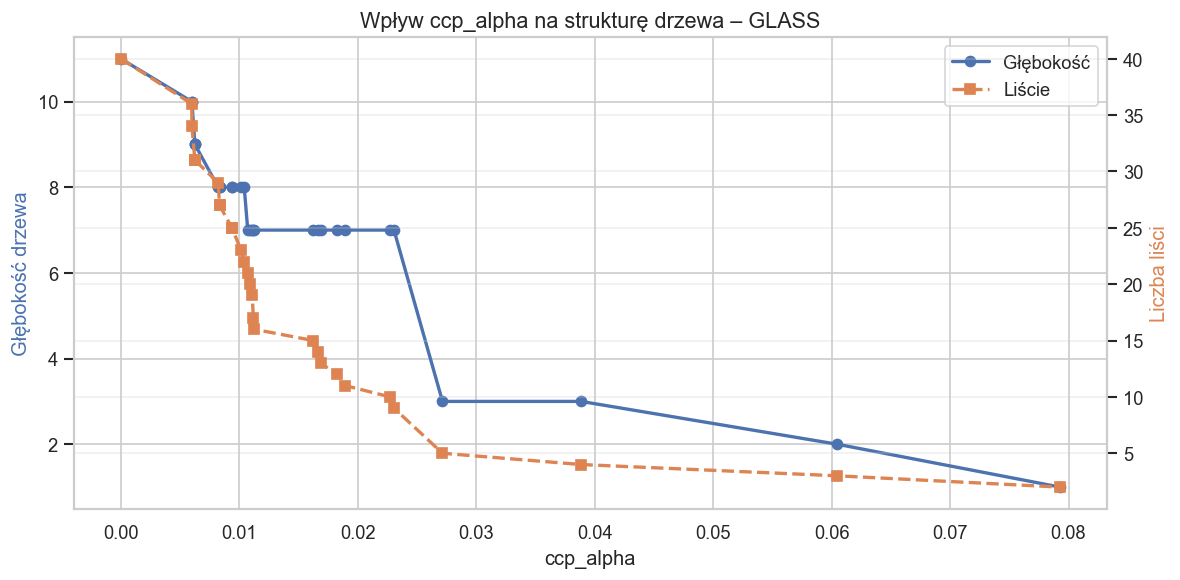

In [59]:
fig, ax = plt.subplots(figsize=(10, 5))
ax2 = ax.twinx()
ax.plot(alphas_test, depth_ccp,  'o-', color='#4C72B0', linewidth=2, label='Głębokość')
ax2.plot(alphas_test, leaves_ccp, 's--', color='#DD8452', linewidth=2, label='Liście')
ax.set_xlabel('ccp_alpha')
ax.set_ylabel('Głębokość drzewa', color='#4C72B0')
ax2.set_ylabel('Liczba liści', color='#DD8452')
ax.set_title('Wpływ ccp_alpha na strukturę drzewa – GLASS', fontsize=13)
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, loc='upper right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 3.4 Wizualizacja wybranych drzew po strojeniu

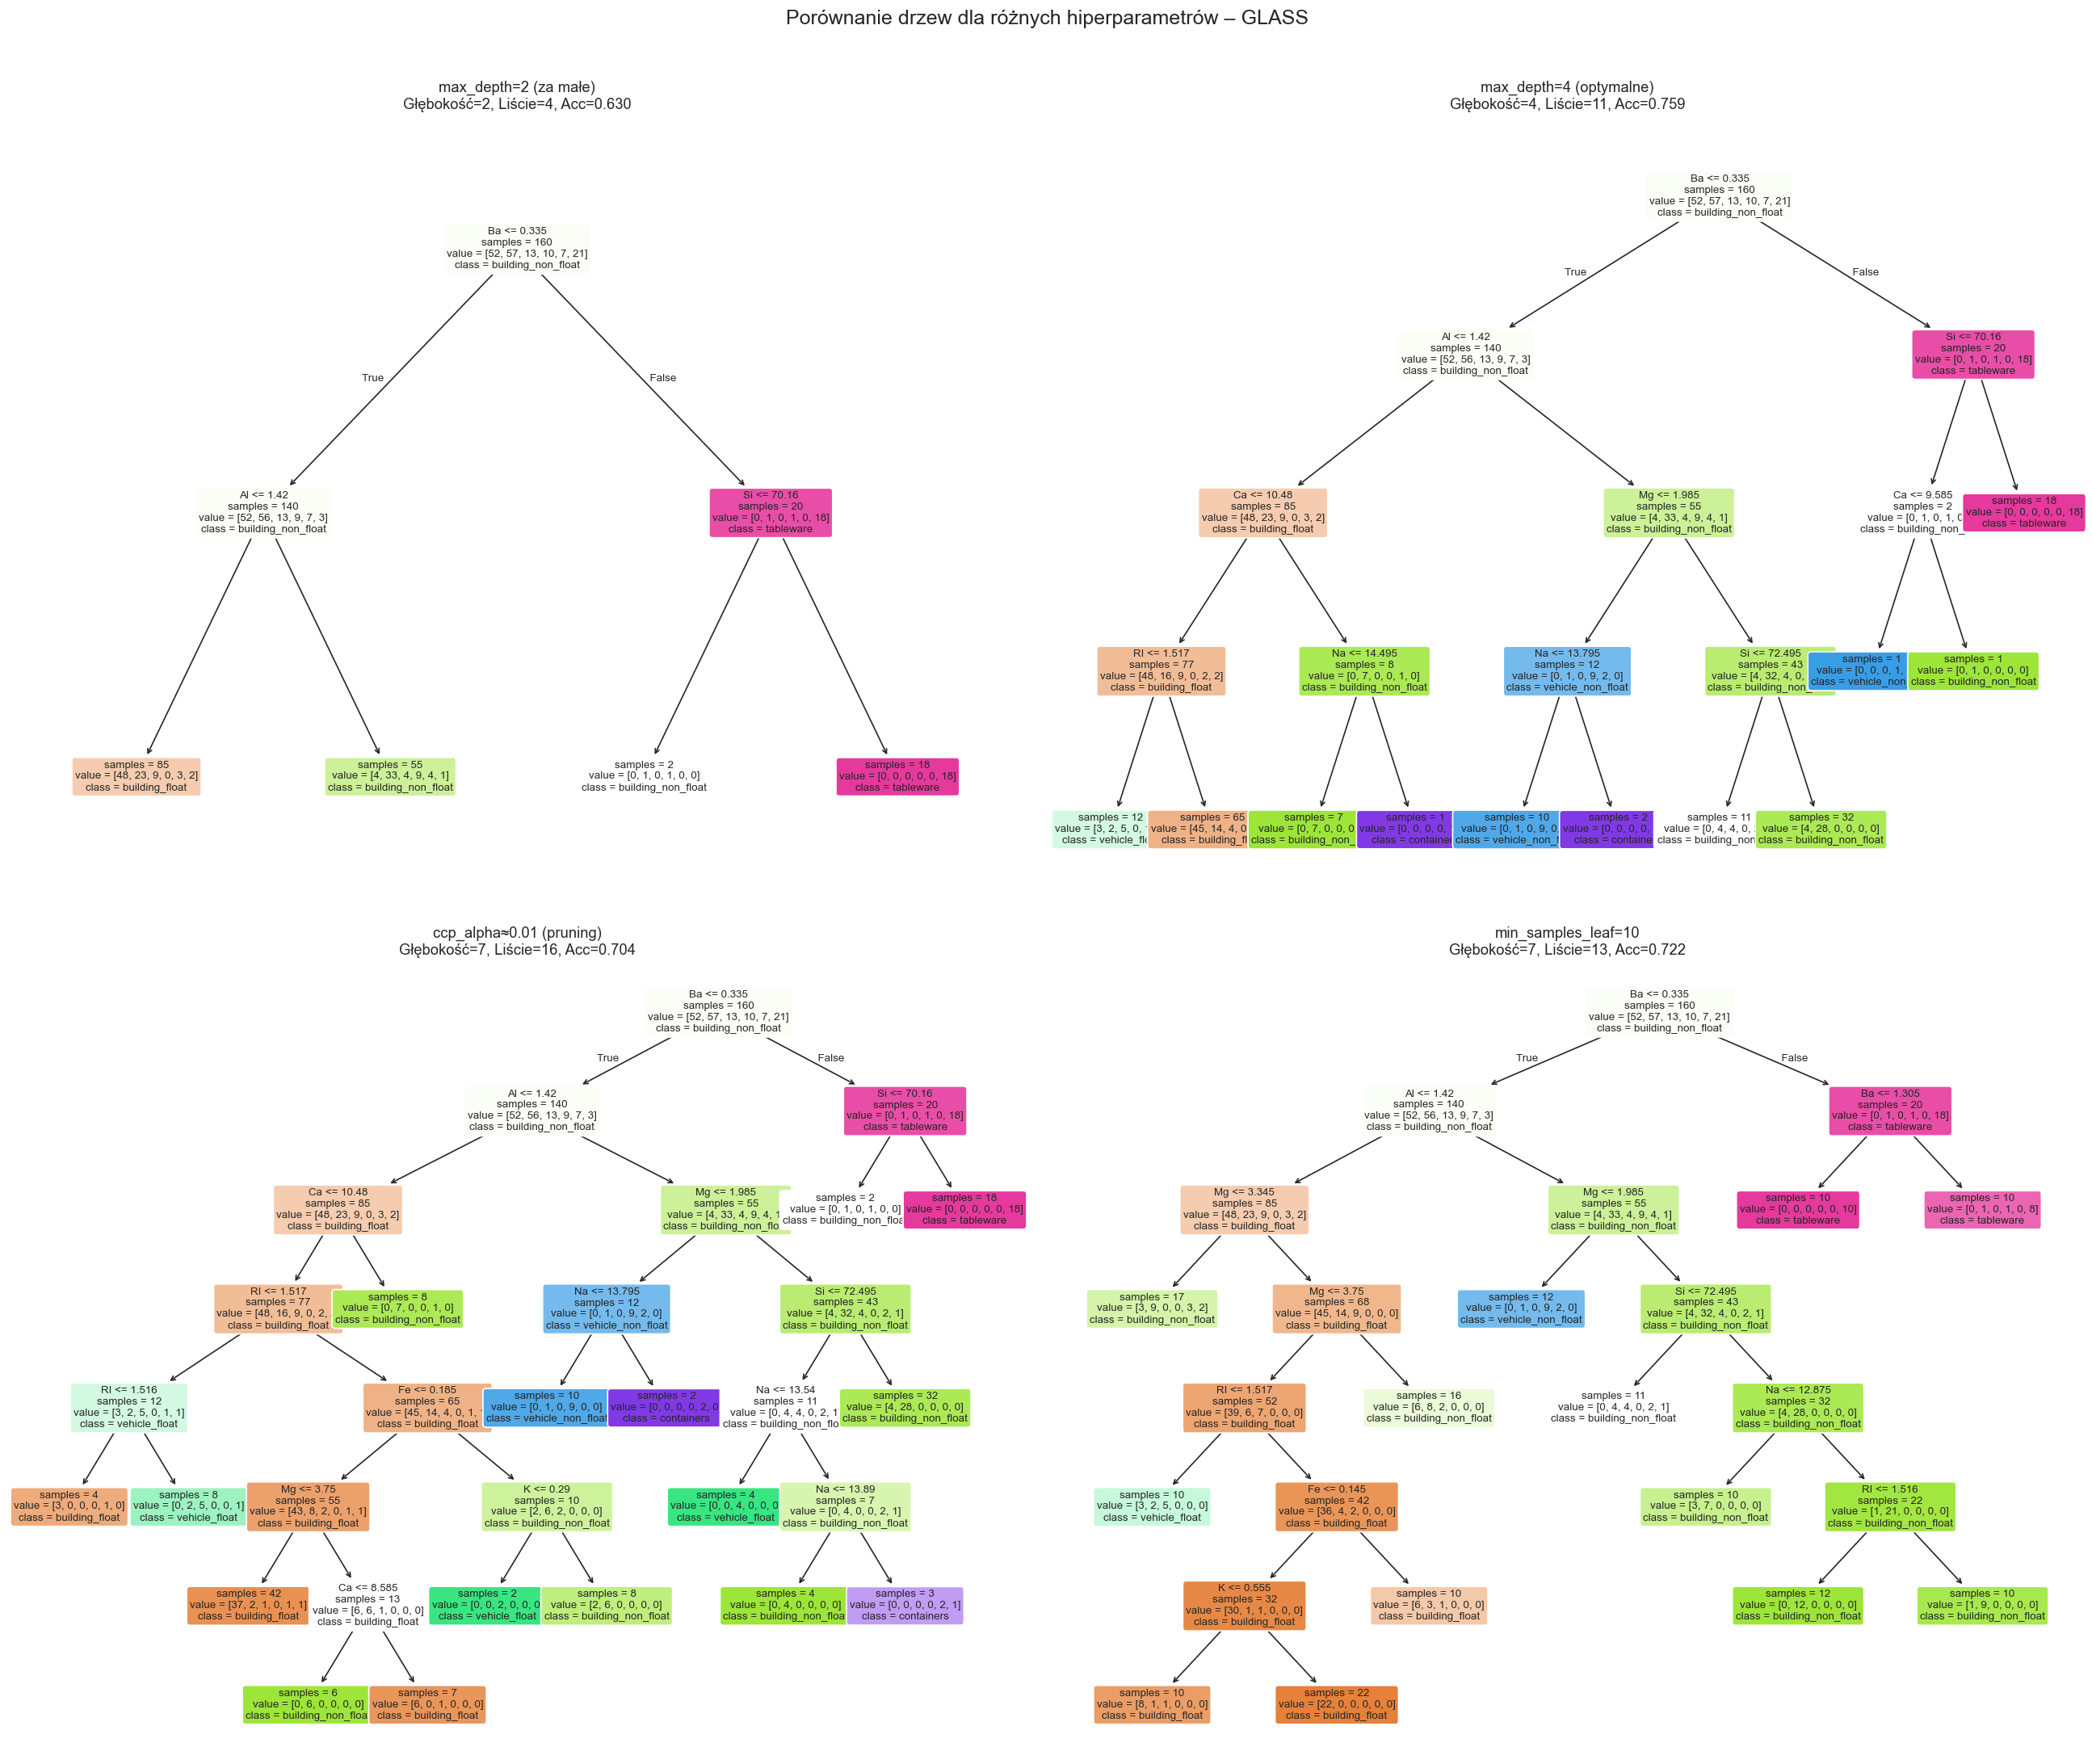

In [ ]:
configs = {
    'max_depth=2 (za małe)':      dict(max_depth=2),
    'max_depth=4 (optymalne)':    dict(max_depth=4),
    'ccp_alpha≈0.01 (pruning)':   dict(ccp_alpha=0.012),
    'min_samples_leaf=10':        dict(min_samples_leaf=10),
}

fig, axes = plt.subplots(2, 2, figsize=(22, 18))
axes = axes.flatten()

for ax, (title, params) in zip(axes, configs.items()):
    clf = DecisionTreeClassifier(**params)
    clf.fit(X_tr_g, y_tr_g)
    acc = accuracy_score(y_te_g, clf.predict(X_te_g))
    plot_tree(clf, ax=ax, feature_names=X_glass.columns.tolist(),
              class_names=target_names_glass,
              filled=True, rounded=True, impurity=False, fontsize=8)
    ax.set_title(
        f'{title}\nGłębokość={clf.get_depth()}, '
        f'Liście={clf.get_n_leaves()}, Acc={acc:.3f}',
        fontsize=11
    )

plt.suptitle('Porównanie drzew dla różnych hiperparametrów – GLASS', fontsize=15, y=1.01)
plt.tight_layout()
plt.show()

### 3.5 Ważność cech

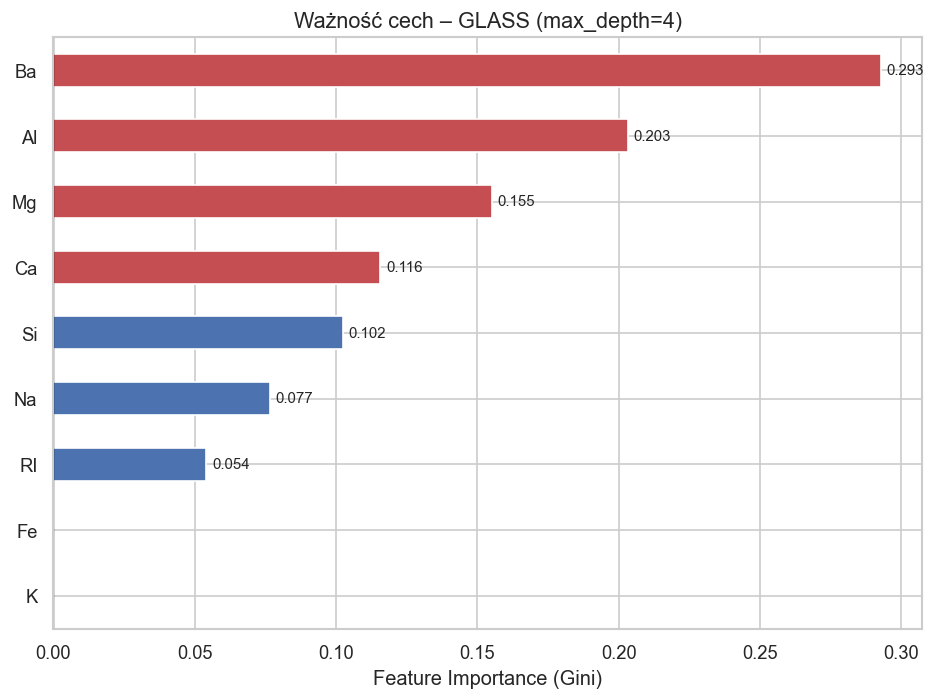

> Cecha flavanoids i proline dominują w klasyfikacji.


In [ ]:
clf_opt = DecisionTreeClassifier(max_depth=4)
clf_opt.fit(X_tr_g, y_tr_g)

importances = pd.Series(clf_opt.feature_importances_, index=X_glass.columns.tolist())
importances = importances.sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 6))
colors_fi = ['#C44E52' if v > importances.median() else '#4C72B0'
             for v in importances.values]
importances.plot.barh(ax=ax, color=colors_fi, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Ważność cech – GLASS (max_depth=4)', fontsize=13)
ax.set_xlabel('Feature Importance (Gini)')
for i, v in enumerate(importances.values):
    if v > 0.01:
        ax.text(v + 0.002, i, f'{v:.3f}', va='center', fontsize=9)
plt.tight_layout()
plt.show()
print('> Cecha flavanoids i proline dominują w klasyfikacji.')

### 3.6 Heatmapa – siatka hiperparametrów (max_depth × min_samples_leaf)

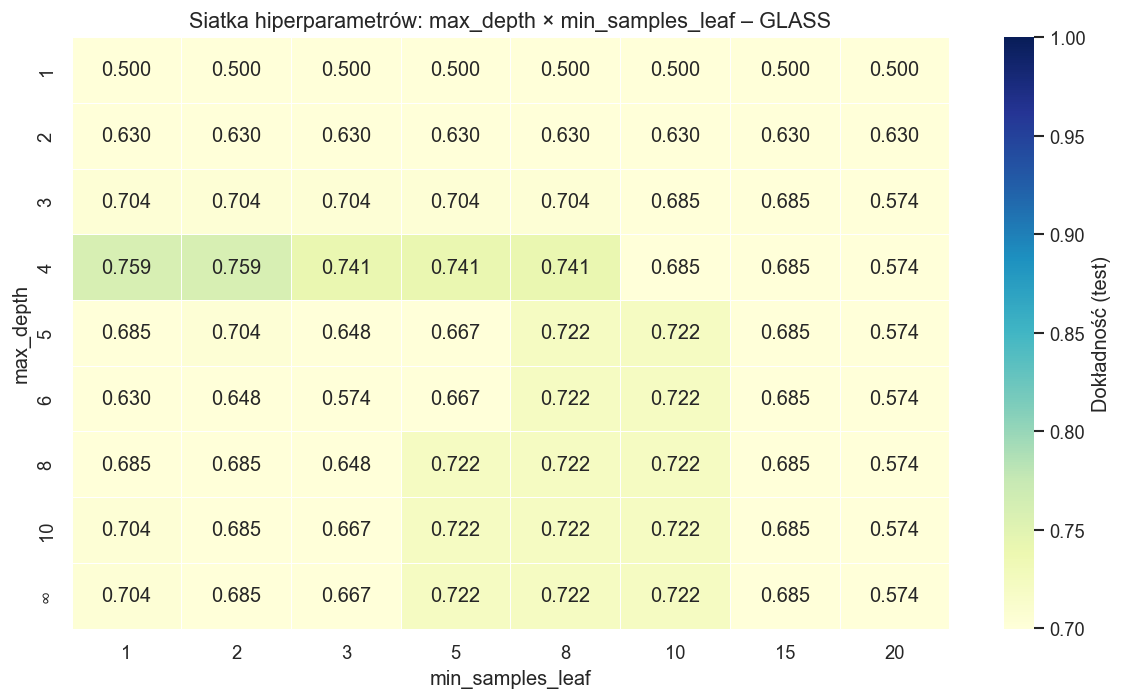

In [ ]:
depths_grid = [1, 2, 3, 4, 5, 6, 8, 10, None]
msl_grid = [1, 2, 3, 5, 8, 10, 15, 20]

heat_matrix = np.zeros((len(depths_grid), len(msl_grid)))

for i, d in enumerate(depths_grid):
    for j, msl in enumerate(msl_grid):
        clf = DecisionTreeClassifier(max_depth=d, min_samples_leaf=msl)
        clf.fit(X_tr_g, y_tr_g)
        heat_matrix[i, j] = accuracy_score(y_te_g, clf.predict(X_te_g))

heat_df = pd.DataFrame(
    heat_matrix,
    index=[str(d) if d else '∞' for d in depths_grid],
    columns=msl_grid
)

fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(heat_df, ax=ax, annot=True, fmt='.3f',
            cmap='YlGnBu', vmin=0.7, vmax=1.0,
            linewidths=0.5, linecolor='white',
            cbar_kws={'label': 'Dokładność (test)'})
ax.set_xlabel('min_samples_leaf', fontsize=12)
ax.set_ylabel('max_depth', fontsize=12)
ax.set_title('Siatka hiperparametrów: max_depth × min_samples_leaf – GLASS',
             fontsize=13)
plt.tight_layout()
plt.show()

---
## 4. Walidacja krzyżowa – zwykła vs. stratyfikowana

In [ ]:
k_folds = 10
clf_cv = DecisionTreeClassifier(max_depth=4)

kf   = KFold(n_splits=k_folds, shuffle=True)
skf  = StratifiedKFold(n_splits=k_folds, shuffle=True)

scores_kf  = cross_val_score(clf_cv, X_glass, y_glass, cv=kf,  scoring='accuracy')
scores_skf = cross_val_score(clf_cv, X_glass, y_glass, cv=skf, scoring='accuracy')

print(f'KFold:            mean={scores_kf.mean():.4f}  std={scores_kf.std():.4f}')
print(f'Stratified KFold: mean={scores_skf.mean():.4f}  std={scores_skf.std():.4f}')

KFold:            mean=0.6643  std=0.1244
Stratified KFold: mean=0.6916  std=0.0567


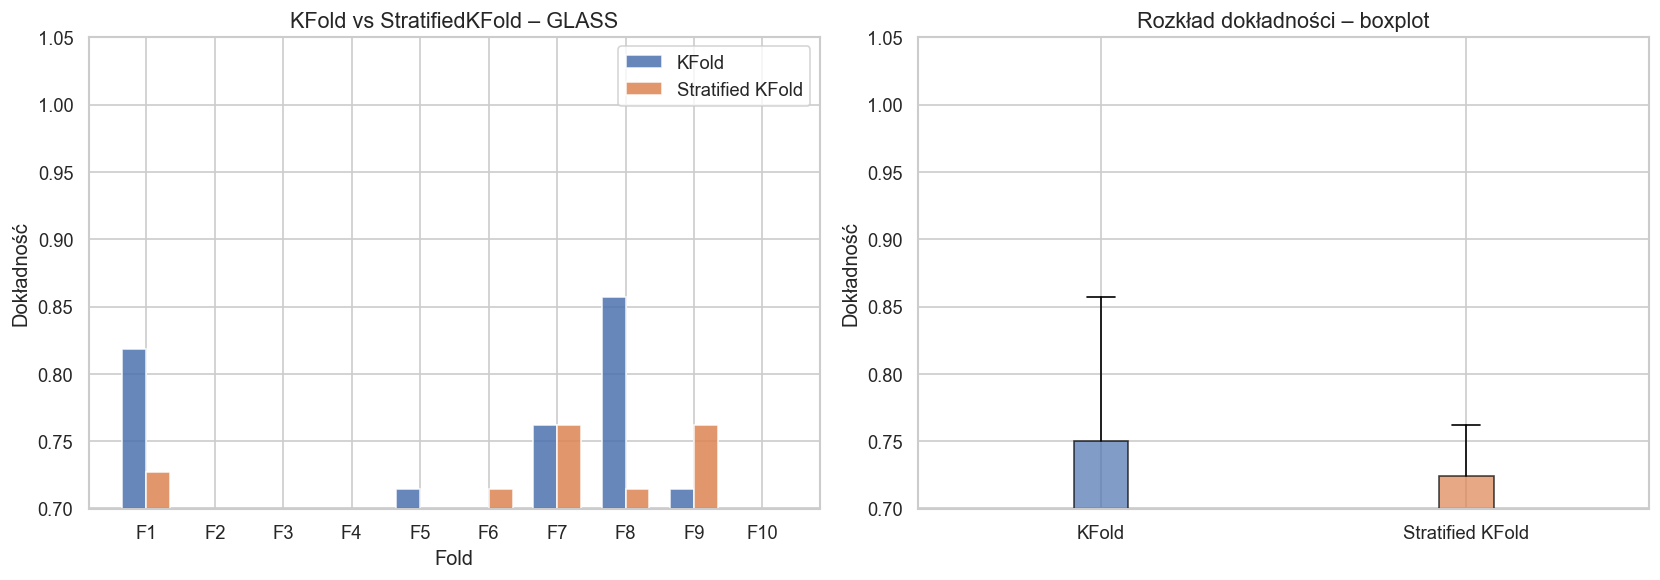

In [64]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

x_pos = np.arange(k_folds)
w = 0.35
axes[0].bar(x_pos - w/2, scores_kf,  w, label='KFold',            color='#4C72B0', alpha=0.85)
axes[0].bar(x_pos + w/2, scores_skf, w, label='Stratified KFold', color='#DD8452', alpha=0.85)
axes[0].axhline(scores_kf.mean(),  color='#4C72B0', linestyle='--', alpha=0.7)
axes[0].axhline(scores_skf.mean(), color='#DD8452', linestyle='--', alpha=0.7)
axes[0].set_xlabel('Fold')
axes[0].set_ylabel('Dokładność')
axes[0].set_title('KFold vs StratifiedKFold – GLASS', fontsize=13)
axes[0].set_xticks(x_pos); axes[0].set_xticklabels([f'F{i+1}' for i in x_pos])
axes[0].set_ylim(0.7, 1.05)
axes[0].legend()

data_bp = [scores_kf, scores_skf]
bp = axes[1].boxplot(data_bp, patch_artist=True,
                     labels=['KFold', 'Stratified KFold'],
                     medianprops={'color':'black','linewidth':2})
for patch, color in zip(bp['boxes'], ['#4C72B0','#DD8452']):
    patch.set_facecolor(color); patch.set_alpha(0.7)
axes[1].set_ylabel('Dokładność')
axes[1].set_title('Rozkład dokładności – boxplot', fontsize=13)
axes[1].set_ylim(0.7, 1.05)

plt.tight_layout()
plt.show()

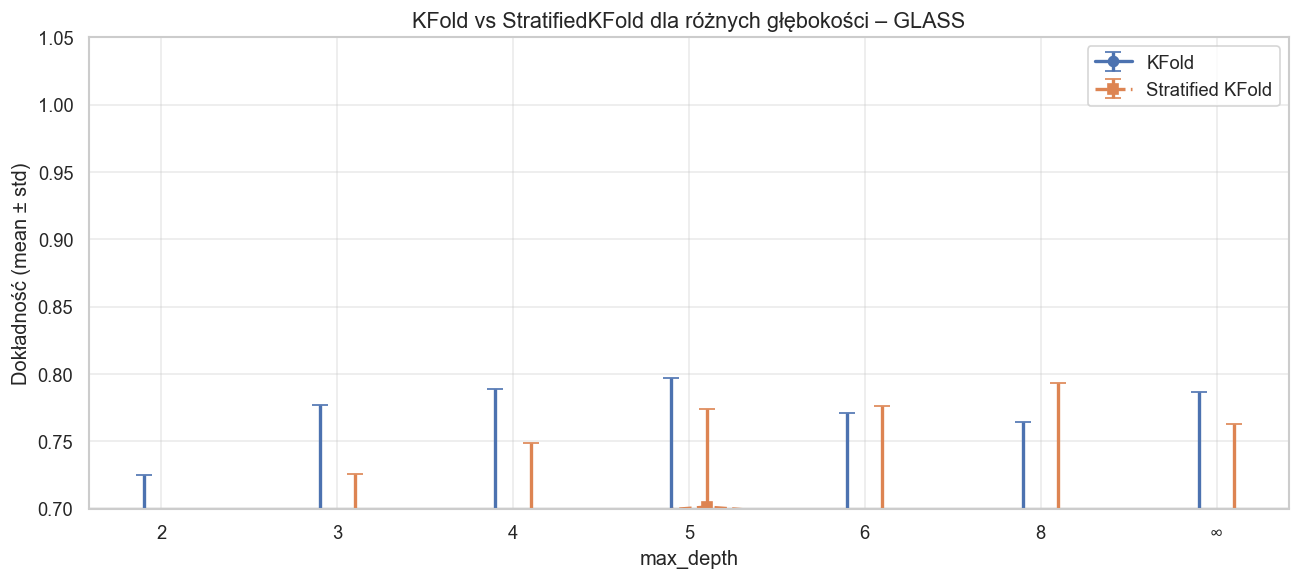

depth  KFold_mean  KFold_std  SKF_mean  SKF_std
    2      0.6080     0.1168    0.6074   0.0314
    3      0.6732     0.1037    0.6725   0.0531
    4      0.6643     0.1244    0.6916   0.0567
    5      0.6600     0.1372    0.7011   0.0730
    6      0.6498     0.1215    0.6916   0.0845
    8      0.6500     0.1140    0.6920   0.1009
    ∞      0.6597     0.1267    0.6779   0.0848


In [ ]:
depths_cv = [2, 3, 4, 5, 6, 8, None]
results_cv = []

for d in depths_cv:
    clf_d = DecisionTreeClassifier(max_depth=d)
    kf_s   = cross_val_score(clf_d, X_glass, y_glass, cv=kf,  scoring='accuracy')
    skf_s  = cross_val_score(clf_d, X_glass, y_glass, cv=skf, scoring='accuracy')
    results_cv.append({'depth': str(d) if d else '∞',
                       'KFold_mean': kf_s.mean(), 'KFold_std': kf_s.std(),
                       'SKF_mean': skf_s.mean(), 'SKF_std': skf_s.std()})

cv_df = pd.DataFrame(results_cv)

fig, ax = plt.subplots(figsize=(11, 5))
x = np.arange(len(depths_cv))
ax.errorbar(x-0.1, cv_df['KFold_mean'], yerr=cv_df['KFold_std'],
            fmt='o-', capsize=5, label='KFold', color='#4C72B0', linewidth=2)
ax.errorbar(x+0.1, cv_df['SKF_mean'], yerr=cv_df['SKF_std'],
            fmt='s--', capsize=5, label='Stratified KFold', color='#DD8452', linewidth=2)
ax.set_xticks(x); ax.set_xticklabels(cv_df['depth'])
ax.set_xlabel('max_depth')
ax.set_ylabel('Dokładność (mean ± std)')
ax.set_title('KFold vs StratifiedKFold dla różnych głębokości – GLASS', fontsize=13)
ax.legend()
ax.grid(True, alpha=0.4)
ax.set_ylim(0.7, 1.05)
plt.tight_layout()
plt.show()
print(cv_df.round(4).to_string(index=False))

---
## 5. Krzywa uczenia (Learning Curve)

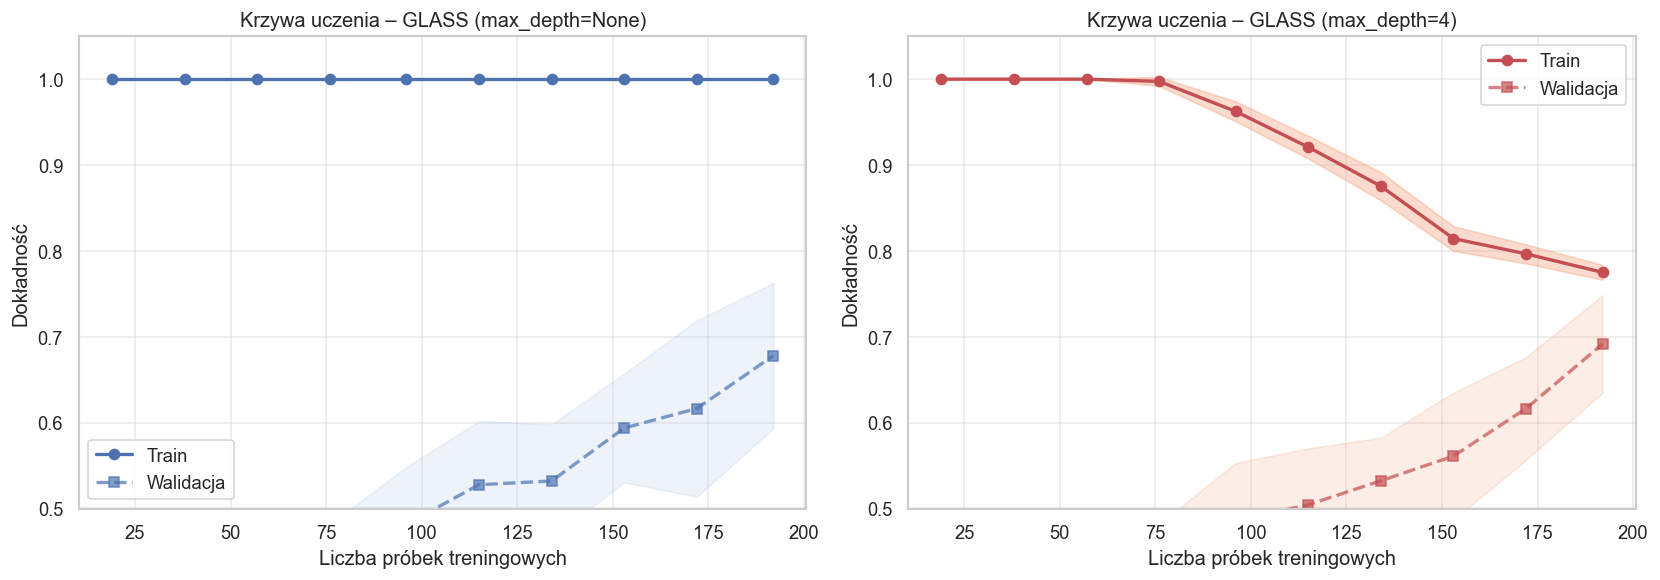

> Lewy wykres (bez ograniczeń): duży gap train vs val → overfitting.
> Prawy wykres (max_depth=4): gap mniejszy → lepiej uogólnia.


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (depth, color_pair) in zip(axes, [
    (None, ('#4C72B0','#AEC6E8')),
    (4,    ('#C44E52','#F4A582'))
]):
    clf_lc = DecisionTreeClassifier(max_depth=depth)
    train_sizes, train_scores, val_scores = learning_curve(
        clf_lc, X_glass, y_glass, cv=skf, scoring='accuracy',
        train_sizes=np.linspace(0.1, 1.0, 10), n_jobs=-1
    )
    tr_mean = train_scores.mean(axis=1)
    tr_std  = train_scores.std(axis=1)
    va_mean = val_scores.mean(axis=1)
    va_std  = val_scores.std(axis=1)

    ax.plot(train_sizes, tr_mean, 'o-', color=color_pair[0], label='Train', linewidth=2)
    ax.fill_between(train_sizes, tr_mean - tr_std, tr_mean + tr_std,
                    color=color_pair[1], alpha=0.4)
    ax.plot(train_sizes, va_mean, 's--', color=color_pair[0], label='Walidacja', linewidth=2, alpha=0.7)
    ax.fill_between(train_sizes, va_mean - va_std, va_mean + va_std,
                    color=color_pair[1], alpha=0.2)
    ax.set_xlabel('Liczba próbek treningowych')
    ax.set_ylabel('Dokładność')
    label = f'max_depth={depth}' if depth else 'max_depth=None'
    ax.set_title(f'Krzywa uczenia – GLASS ({label})', fontsize=12)
    ax.legend()
    ax.grid(True, alpha=0.4)
    ax.set_ylim(0.5, 1.05)

plt.tight_layout()
plt.show()
print('> Lewy wykres (bez ograniczeń): duży gap train vs val → overfitting.')
print('> Prawy wykres (max_depth=4): gap mniejszy → lepiej uogólnia.')

---
## 6. Wpływ wag klas – PCB

In [ ]:
X_tr_p, X_te_p, y_tr_p, y_te_p = train_test_split(
    X_pcb_imp, y_pcb_s, test_size=0.25,
    stratify=y_pcb_s
)

print(f'Train: {y_tr_p.value_counts().to_dict()}')
print(f'Test:  {y_te_p.value_counts().to_dict()}')

Train: {0: 30985, 1: 1568}
Test:  {0: 10329, 1: 523}


In [ ]:
weight_configs = {
    'Bez wag (None)':      None,
    'Balanced':            'balanced',
    'Manual 1:5':         {0: 1, 1: 5},
    'Manual 1:10':        {0: 1, 1: 10},
    'Manual 1:20':        {0: 1, 1: 20},
}

results_pcb = []
for label, cw in weight_configs.items():
    clf_pcb = DecisionTreeClassifier(
        max_depth=5, class_weight=cw
    )
    clf_pcb.fit(X_tr_p, y_tr_p)
    y_pred_p = clf_pcb.predict(X_te_p)
    results_pcb.append({
        'Konfiguracja': label,
        'Accuracy':     accuracy_score(y_te_p, y_pred_p),
        'F1 (bankrupt)': f1_score(y_te_p, y_pred_p, pos_label=1),
        'F1 (macro)':   f1_score(y_te_p, y_pred_p, average='macro'),
        'Recall (1)':   classification_report(y_te_p, y_pred_p, output_dict=True)['1']['recall'],
        'Precision (1)': classification_report(y_te_p, y_pred_p, output_dict=True)['1']['precision'],
    })

res_df = pd.DataFrame(results_pcb)
print(res_df.round(4).to_string(index=False))

  Konfiguracja  Accuracy  F1 (bankrupt)  F1 (macro)  Recall (1)  Precision (1)
Bez wag (None)    0.9582         0.3015      0.6400      0.1874         0.7717
      Balanced    0.7647         0.2345      0.5477      0.7476         0.1390
    Manual 1:5    0.9579         0.4208      0.6995      0.3174         0.6241
   Manual 1:10    0.8474         0.2929      0.6037      0.6558         0.1886
   Manual 1:20    0.7647         0.2345      0.5477      0.7476         0.1390


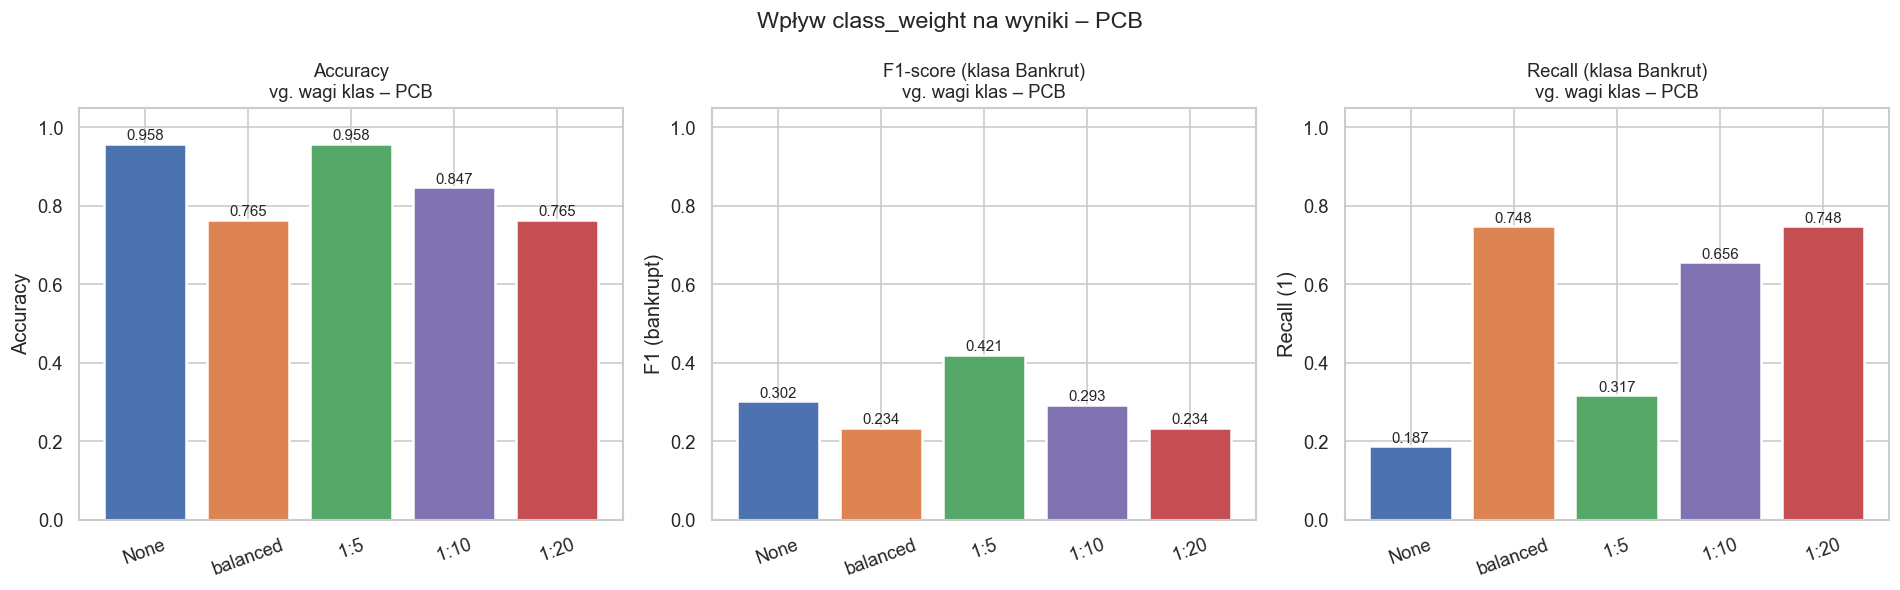

In [69]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
labels_short = ['None', 'balanced', '1:5', '1:10', '1:20']
x = np.arange(len(labels_short))
bar_colors = ['#4C72B0','#DD8452','#55A868','#8172B2','#C44E52']

for ax, col, title in zip(axes,
    ['Accuracy', 'F1 (bankrupt)', 'Recall (1)'],
    ['Accuracy', 'F1-score (klasa Bankrut)', 'Recall (klasa Bankrut)']):
    bars = ax.bar(x, res_df[col], color=bar_colors, edgecolor='white', linewidth=1.5)
    ax.set_xticks(x); ax.set_xticklabels(labels_short, rotation=20)
    ax.set_title(f'{title}\nvg. wagi klas – PCB', fontsize=11)
    ax.set_ylabel(col)
    ax.set_ylim(0, 1.05)
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.01,
                f'{bar.get_height():.3f}',
                ha='center', fontsize=9)

plt.suptitle('Wpływ class_weight na wyniki – PCB', fontsize=14)
plt.tight_layout()
plt.show()

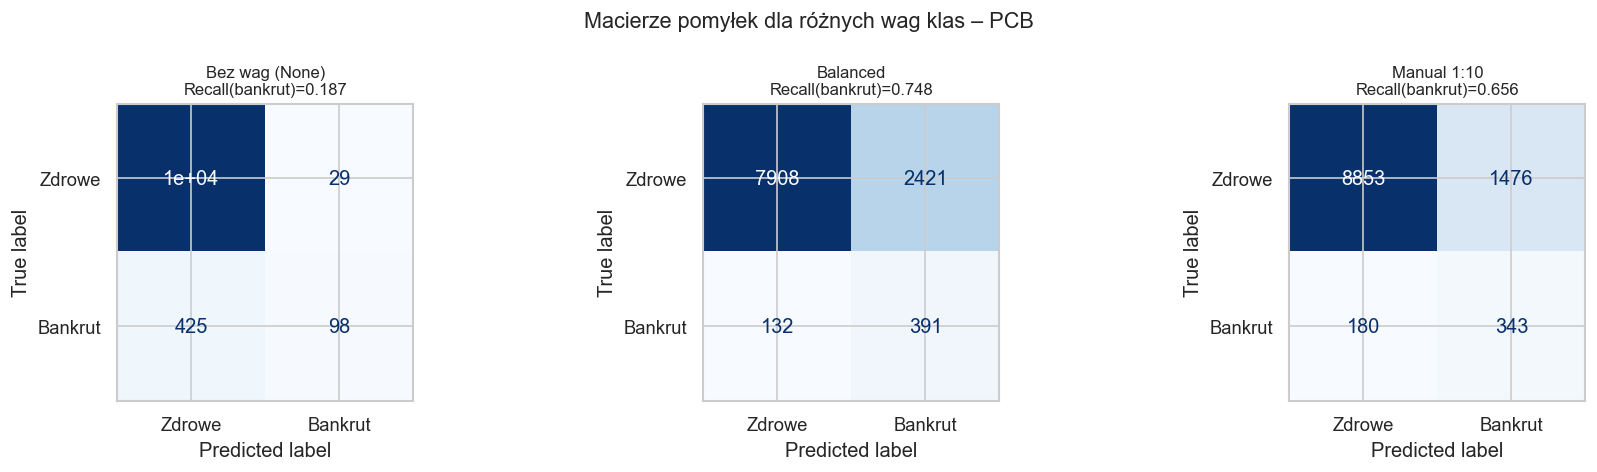

In [70]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
selected = [
    ('Bez wag (None)', None),
    ('Balanced',       'balanced'),
    ('Manual 1:10',   {0:1, 1:10}),
]

for ax, (label, cw) in zip(axes, selected):
    clf_p = DecisionTreeClassifier(max_depth=5, class_weight=cw)
    clf_p.fit(X_tr_p, y_tr_p)
    y_pred_p = clf_p.predict(X_te_p)
    cm_p = confusion_matrix(y_te_p, y_pred_p)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm_p,
                                  display_labels=['Zdrowe', 'Bankrut'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    rec = cm_p[1,1] / (cm_p[1,0] + cm_p[1,1]) if (cm_p[1,0]+cm_p[1,1]) > 0 else 0
    ax.set_title(f'{label}\nRecall(bankrut)={rec:.3f}', fontsize=10)

plt.suptitle('Macierze pomyłek dla różnych wag klas – PCB', fontsize=13)
plt.tight_layout()
plt.show()

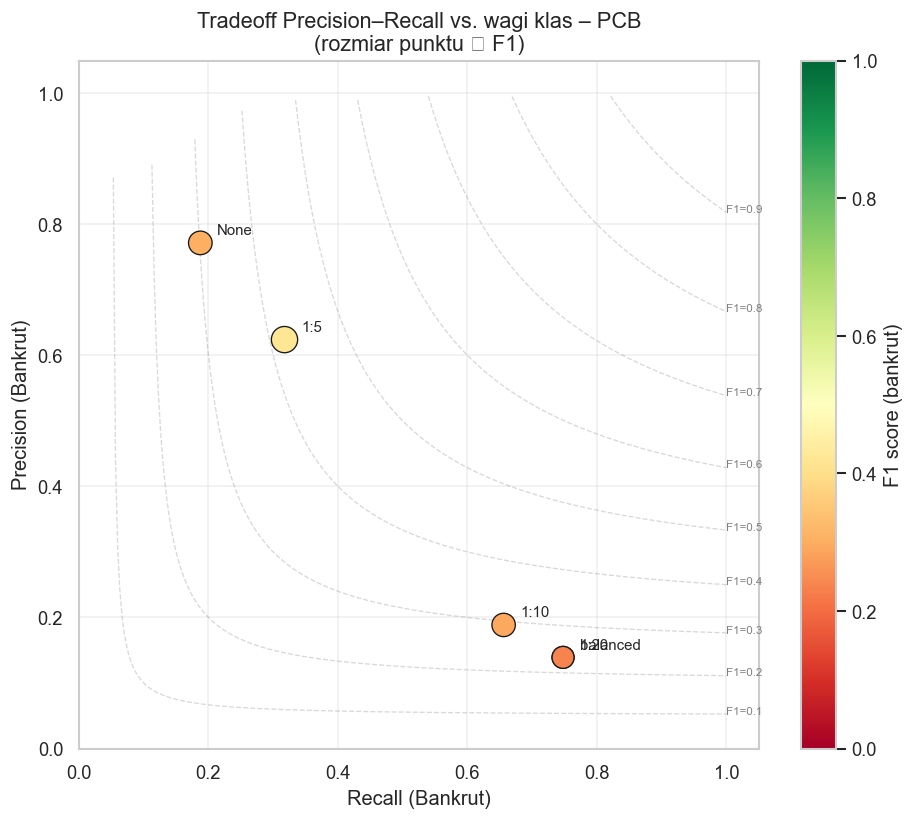

In [71]:
fig, ax = plt.subplots(figsize=(8, 7))

# iso-F1 lines
f1_levels = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
for f1_val in f1_levels:
    recall_range = np.linspace(0.01, 1.0, 300)
    prec_iso = f1_val * recall_range / (2 * recall_range - f1_val)
    mask = (prec_iso >= 0) & (prec_iso <= 1)
    ax.plot(recall_range[mask], prec_iso[mask], '--', color='gray', alpha=0.3, linewidth=0.8)
    idx = mask.nonzero()[0][-1]
    ax.text(recall_range[idx], prec_iso[idx], f'F1={f1_val:.1f}', fontsize=7, color='gray')

# oblicz f1 dla każdej konfiguracji
f1_vals_plot = 2 * res_df['Precision (1)'] * res_df['Recall (1)'] / (
    res_df['Precision (1)'] + res_df['Recall (1)'] + 1e-9)
sizes = 80 + 400 * f1_vals_plot

sc = ax.scatter(res_df['Recall (1)'], res_df['Precision (1)'],
                s=sizes, c=f1_vals_plot, cmap='RdYlGn',
                vmin=0, vmax=1, zorder=5, edgecolors='k', linewidth=0.8)

for i, row in res_df.iterrows():
    ax.annotate(labels_short[i],
                (row['Recall (1)'], row['Precision (1)']),
                textcoords='offset points', xytext=(10, 5), fontsize=9,
                arrowprops=dict(arrowstyle='->', color='gray', lw=0.8))

plt.colorbar(sc, ax=ax, label='F1 score (bankrut)')
ax.set_xlabel('Recall (Bankrut)', fontsize=12)
ax.set_ylabel('Precision (Bankrut)', fontsize=12)
ax.set_title('Tradeoff Precision–Recall vs. wagi klas – PCB\n(rozmiar punktu ∝ F1)', fontsize=13)
ax.set_xlim(0, 1.05); ax.set_ylim(0, 1.05)
ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()


---
## 7. Walidacja stratyfikowana vs. zwykła – PCB

In [72]:
clf_pcb_cv = DecisionTreeClassifier(max_depth=5, class_weight='balanced')

kf_p  = KFold(n_splits=10, shuffle=True)
skf_p = StratifiedKFold(n_splits=10, shuffle=True)

for metric in ['accuracy', 'f1', 'recall']:
    sc_kf  = cross_val_score(clf_pcb_cv, X_pcb_imp, y_pcb_s, cv=kf_p,  scoring=metric)
    sc_skf = cross_val_score(clf_pcb_cv, X_pcb_imp, y_pcb_s, cv=skf_p, scoring=metric)
    print(f'{metric:10s} | KFold: {sc_kf.mean():.4f} ± {sc_kf.std():.4f}  '
          f'| StratKFold: {sc_skf.mean():.4f} ± {sc_skf.std():.4f}')

accuracy   | KFold: 0.7834 ± 0.0141  | StratKFold: 0.7754 ± 0.0251


KeyboardInterrupt: 

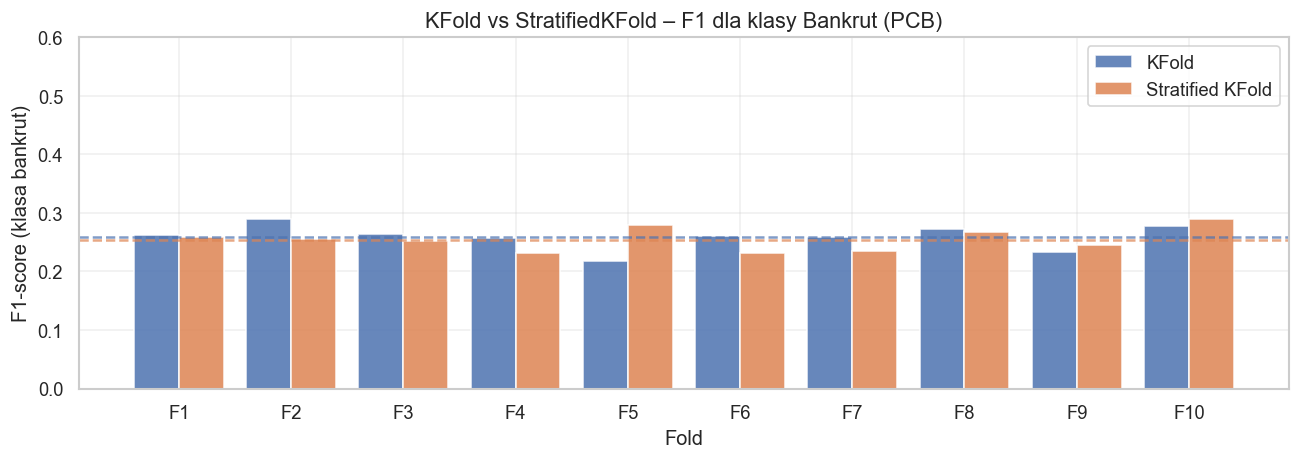

KFold std=0.0197   Stratified std=0.0188
> Przy niezbalansowanych danych KFold może przypadkowo wkładać wszystkie
  bankroty do jednego folda → wysoka wariancja. Stratyfikacja to stabilizuje.


In [ ]:
# Wizualizacja wariancji foldów dla PCB
sc_kf_f1  = cross_val_score(clf_pcb_cv, X_pcb_imp, y_pcb_s, cv=kf_p,  scoring='f1')
sc_skf_f1 = cross_val_score(clf_pcb_cv, X_pcb_imp, y_pcb_s, cv=skf_p, scoring='f1')

fig, ax = plt.subplots(figsize=(11, 4))
x10 = np.arange(10)
ax.bar(x10 - 0.2, sc_kf_f1,  0.4, label='KFold',            color='#4C72B0', alpha=0.85)
ax.bar(x10 + 0.2, sc_skf_f1, 0.4, label='Stratified KFold', color='#DD8452', alpha=0.85)
ax.axhline(sc_kf_f1.mean(),  color='#4C72B0', linestyle='--', alpha=0.7)
ax.axhline(sc_skf_f1.mean(), color='#DD8452', linestyle='--', alpha=0.7)
ax.set_xlabel('Fold')
ax.set_ylabel('F1-score (klasa bankrut)')
ax.set_title('KFold vs StratifiedKFold – F1 dla klasy Bankrut (PCB)', fontsize=13)
ax.set_xticks(x10); ax.set_xticklabels([f'F{i+1}' for i in x10])
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_ylim(0, 0.6)
plt.tight_layout()
plt.show()
print(f'KFold std={sc_kf_f1.std():.4f}   Stratified std={sc_skf_f1.std():.4f}')
print('> Przy niezbalansowanych danych KFold może przypadkowo wkładać wszystkie')
print('  bankroty do jednego folda → wysoka wariancja. Stratyfikacja to stabilizuje.')

---
## 8. Podsumowanie wyników

In [ ]:
summary_glass = []
configs_summary = [
    ('Domyślne (brak ograniczeń)', {}),
    ('max_depth=2',                {'max_depth': 2}),
    ('max_depth=4',                {'max_depth': 4}),
    ('max_depth=6',                {'max_depth': 6}),
    ('min_samples_leaf=5',         {'min_samples_leaf': 5}),
    ('ccp_alpha=0.012',            {'ccp_alpha': 0.012}),
    ('depth=4 + msl=3',            {'max_depth': 4, 'min_samples_leaf': 3}),
]

for name, params in configs_summary:
    clf = DecisionTreeClassifier(**params)
    cv_s = cross_val_score(clf, X_glass, y_glass, cv=skf, scoring='accuracy')
    clf.fit(X_tr_g, y_tr_g)
    summary_glass.append({
        'Konfiguracja': name,
        'Głębokość': clf.get_depth(),
        'Liście': clf.get_n_leaves(),
        'Acc Test': accuracy_score(y_te_g, clf.predict(X_te_g)),
        'CV mean': cv_s.mean(),
        'CV std': cv_s.std(),
    })

sum_df = pd.DataFrame(summary_glass)
print(sum_df.round(4).to_string(index=False))

              Konfiguracja  Głębokość  Liście  Acc Test  CV mean  CV std
Domyślne (brak ograniczeń)          4       8    0.9556   0.8997  0.0776
               max_depth=2          2       4    0.8667   0.8487  0.0746
               max_depth=4          4       8    0.9556   0.8830  0.0720
               max_depth=6          4       8    0.9556   0.8997  0.0776
        min_samples_leaf=5          3       6    0.9556   0.8889  0.0930
           ccp_alpha=0.012          4       8    0.9556   0.9056  0.0826
           depth=4 + msl=3          4       7    0.9556   0.8775  0.0775


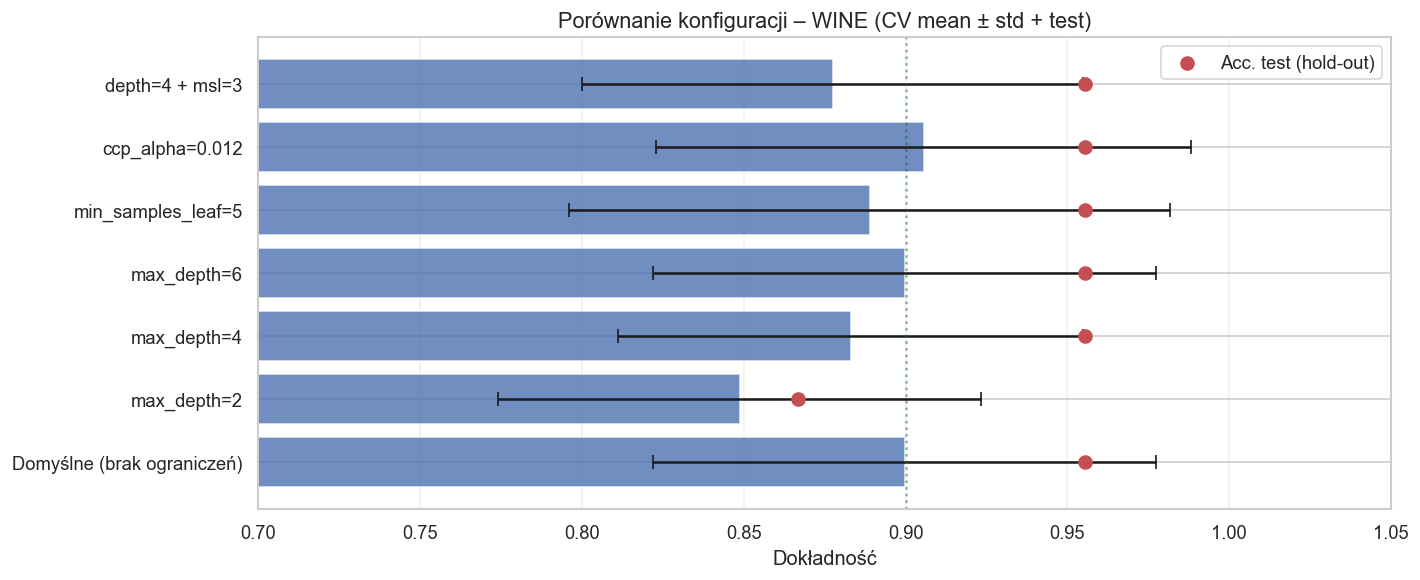

In [ ]:
# Wykres podsumowujący GLASS
fig, ax = plt.subplots(figsize=(12, 5))
y_pos = np.arange(len(sum_df))

bars = ax.barh(y_pos, sum_df['CV mean'],
               xerr=sum_df['CV std'], capsize=4,
               color='#4C72B0', alpha=0.8, edgecolor='white')
ax.scatter(sum_df['Acc Test'], y_pos, color='#C44E52',
           zorder=5, s=60, label='Acc. test (hold-out)')
ax.set_yticks(y_pos)
ax.set_yticklabels(sum_df['Konfiguracja'])
ax.set_xlabel('Dokładność')
ax.set_title('Porównanie konfiguracji – GLASS (CV mean ± std + test)', fontsize=13)
ax.axvline(0.9, color='green', linestyle=':', alpha=0.5)
ax.legend()
ax.set_xlim(0.7, 1.05)
ax.grid(True, axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

---
## 9. Granica decyzyjna – GLASS (PCA 2D)

Redukujemy dane do 2 wymiarów (PCA) i rysujemy granicę decyzyjną dla różnych `max_depth`.

In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_glass_2d = pca.fit_transform(X_glass)

depths_vis = [1, 2, 4, 8, None]
titles = ['depth=1', 'depth=2', 'depth=4', 'depth=8', 'depth=None (pełne)']

x_min, x_max = X_glass_2d[:, 0].min() - 0.5, X_glass_2d[:, 0].max() + 0.5
y_min, y_max = X_glass_2d[:, 1].min() - 0.5, X_glass_2d[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                     np.linspace(y_min, y_max, 300))

palette6 = ['#4878D0','#EE854A','#6ACC65','#D65F5F','#956CB4','#8C613C']
class_vals = sorted(y_glass.unique())
cmap_bg = ListedColormap([c + '55' for c in palette6])
cmap_pt = ListedColormap(palette6)
val_to_idx = {v: ii for ii, v in enumerate(class_vals)}
y_idx = y_glass.map(val_to_idx).values

fig, axes = plt.subplots(1, 5, figsize=(22, 4))
for ax, d, title in zip(axes, depths_vis, titles):
    clf = DecisionTreeClassifier(max_depth=d)
    clf.fit(X_glass_2d, y_idx)
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.35, cmap=cmap_bg, levels=np.arange(-0.5, 6, 1))
    ax.scatter(X_glass_2d[:, 0], X_glass_2d[:, 1],
               c=y_idx, cmap=cmap_pt, s=18, edgecolors='k', lw=0.3)
    ax.set_title(title, fontsize=11)
    ax.set_xlabel('PC1'); ax.set_ylabel('PC2')

patches = [mpatches.Patch(color=palette6[i], label=target_names_glass[i])
           for i in range(len(class_vals))]
fig.legend(handles=patches, loc='lower center', ncol=6,
           bbox_to_anchor=(0.5, -0.12), fontsize=9)
fig.suptitle('Granica decyzyjna CART – GLASS (PCA 2D)', fontsize=13, y=1.02)
plt.tight_layout(); plt.show()


---
## 10. Stabilność ważności cech vs. `max_depth` – GLASS

Heatmapa pokazuje jak zmienia się ważność każdej cechy gdy zwiększamy głębokość drzewa.

In [ ]:
depths_imp = [1, 2, 3, 4, 5, 6, 8, 10, None]
feat_names = X_glass.columns.tolist()
imp_matrix = np.zeros((len(depths_imp), len(feat_names)))

for ii, d in enumerate(depths_imp):
    clf = DecisionTreeClassifier(max_depth=d)
    clf.fit(X_tr_g, y_tr_g)
    imp_matrix[ii] = clf.feature_importances_

imp_df = pd.DataFrame(imp_matrix,
                      index=[str(d) for d in depths_imp],
                      columns=feat_names)

fig, ax = plt.subplots(figsize=(12, 5))
sns.heatmap(imp_df, annot=True, fmt='.2f', cmap='YlOrRd', ax=ax,
            linewidths=0.4, linecolor='white', vmin=0, vmax=1)
ax.set_xlabel('Cecha', fontsize=12)
ax.set_ylabel('max_depth', fontsize=12)
ax.set_title('Stabilność ważności cech vs max_depth – GLASS', fontsize=13)
plt.tight_layout(); plt.show()


---
## 11. Krzywe ROC – PCB (wpływ `class_weight`)

Dla zbioru niezbalansowanego ROC-AUC pokazuje jak dobrze model rankuje przykłady pozytywne.

In [ ]:
from sklearn.metrics import roc_curve, auc

weight_list = [None, 'balanced', {0:1,1:5}, {0:1,1:10}]
weight_labels = ['None', 'balanced', '{0:1,1:5}', '{0:1,1:10}']
colors_roc = ['#4C72B0','#DD8452','#55A868','#C44E52']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

auc_scores = []
for w, label, color in zip(weight_list, weight_labels, colors_roc):
    clf = DecisionTreeClassifier(max_depth=5, class_weight=w)
    clf.fit(X_tr_p, y_tr_p)
    y_prob = clf.predict_proba(X_te_p)[:, 1]
    fpr, tpr, _ = roc_curve(y_te_p, y_prob)
    roc_auc = auc(fpr, tpr)
    auc_scores.append(roc_auc)
    axes[0].plot(fpr, tpr, color=color, linewidth=2, label=f'{label} (AUC={roc_auc:.3f})')

axes[0].plot([0,1],[0,1],'k--',alpha=0.4)
axes[0].set_xlabel('FPR'); axes[0].set_ylabel('TPR')
axes[0].set_title('ROC – PCB, max_depth=5', fontsize=13)
axes[0].legend(fontsize=9); axes[0].grid(True, alpha=0.3)

# AUC vs max_depth
depths_roc = range(1, 15)
auc_by_depth = []
for d in depths_roc:
    clf = DecisionTreeClassifier(max_depth=d, class_weight='balanced')
    clf.fit(X_tr_p, y_tr_p)
    y_prob = clf.predict_proba(X_te_p)[:, 1]
    auc_by_depth.append(roc_auc_score(y_te_p, y_prob))

axes[1].plot(depths_roc, auc_by_depth, 'o-', color='#4C72B0', linewidth=2)
axes[1].set_xlabel('max_depth'); axes[1].set_ylabel('ROC-AUC')
axes[1].set_title('AUC vs max_depth – PCB (balanced)', fontsize=13)
axes[1].grid(True, alpha=0.4)

plt.tight_layout(); plt.show()


---
## 12. Stabilność modelu – 50 losowych podziałów

Violinplot accuracy i F1 macro dla 4 konfiguracji, 50 random seeds. Szerszy violin = większa wariancja = mniej stabilny model.

In [ ]:
N_RUNS = 50
seeds  = range(N_RUNS)

stability_configs = {
    'Brak ogranicz.\n(None)': dict(),
    'max_depth=4':            dict(max_depth=4),
    'max_depth=4\n+msl=5':   dict(max_depth=4, min_samples_leaf=5),
    'ccp_alpha=0.01':         dict(ccp_alpha=0.01),
}

# GLASS – zbieramy acc i f1_macro
stab_glass = {k: {'acc': [], 'f1': []} for k in stability_configs}
# PCB – zbieramy acc i f1 dla klasy bankrut
stab_pcb   = {k: {'acc': [], 'f1': []} for k in stability_configs}

for seed in seeds:
    Xtrg, Xteg, ytrg, yteg = train_test_split(
        X_glass, y_glass, test_size=0.25, stratify=y_glass)
    Xtrp, Xtep, ytrp, ytep = train_test_split(
        X_pcb_imp, y_pcb_s, test_size=0.25, stratify=y_pcb_s)
    for cfg_name, params in stability_configs.items():
        # GLASS
        clg = DecisionTreeClassifier(**params)
        clg.fit(Xtrg, ytrg); yp = clg.predict(Xteg)
        stab_glass[cfg_name]['acc'].append(accuracy_score(yteg, yp))
        stab_glass[cfg_name]['f1'].append(f1_score(yteg, yp, average='macro'))
        # PCB
        clp = DecisionTreeClassifier(**params, class_weight='balanced')
        clp.fit(Xtrp, ytrp); yp = clp.predict(Xtep)
        stab_pcb[cfg_name]['acc'].append(accuracy_score(ytep, yp))
        stab_pcb[cfg_name]['f1'].append(f1_score(ytep, yp, average='macro'))

print('Zbieranie danych zakończone.')


In [ ]:
cfg_labels = list(stability_configs.keys())
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

def violin_row(ax_viol, ax_viol2, ax_bar, data_dict, metric, title_prefix):
    data_acc = [data_dict[k][metric] for k in cfg_labels]
    vp = ax_viol.violinplot(data_acc, positions=range(len(cfg_labels)), showmedians=True)
    for pc in vp['bodies']: pc.set_alpha(0.7)
    for jj, d in enumerate(data_acc):
        ax_viol.scatter(np.full(len(d), jj) + np.random.uniform(-0.05,0.05,len(d)),
                       d, alpha=0.3, s=8, color='gray')
    ax_viol.set_xticks(range(len(cfg_labels)))
    ax_viol.set_xticklabels(cfg_labels, fontsize=8)
    ax_viol.set_title(f'{title_prefix} – violin', fontsize=11)
    ax_viol.grid(True, alpha=0.3)

    # drugi violin (F1)
    data_f1 = [data_dict[k]['f1'] for k in cfg_labels]
    vp2 = ax_viol2.violinplot(data_f1, positions=range(len(cfg_labels)), showmedians=True)
    for pc in vp2['bodies']: pc.set_alpha(0.7)
    ax_viol2.set_xticks(range(len(cfg_labels)))
    ax_viol2.set_xticklabels(cfg_labels, fontsize=8)
    ax_viol2.set_title(f'{title_prefix} F1 – violin', fontsize=11)
    ax_viol2.grid(True, alpha=0.3)

    # summary bar
    means = [np.mean(d) for d in data_acc]
    stds  = [np.std(d)  for d in data_acc]
    ax_bar.bar(range(len(cfg_labels)), means, yerr=stds, capsize=5,
               color='#4C72B0', alpha=0.8)
    ax_bar.set_xticks(range(len(cfg_labels)))
    ax_bar.set_xticklabels(cfg_labels, fontsize=8)
    ax_bar.set_ylabel('Acc ± std')
    ax_bar.set_title(f'{title_prefix} – mean±std (Acc)', fontsize=11)
    ax_bar.grid(True, alpha=0.3, axis='y')

violin_row(axes[0,0], axes[0,1], axes[0,2], stab_glass, 'acc', 'GLASS Acc')
violin_row(axes[1,0], axes[1,1], axes[1,2], stab_pcb,   'acc', 'PCB Acc')

plt.suptitle('Stabilność modelu CART – 50 losowych podziałów', fontsize=14, y=1.01)
plt.tight_layout(); plt.show()
